# Prediksi Produktivitas dan Produksi Padi
## Provinsi Lampung – Pendekatan Machine Learning Berbasis Musim Tanam (2019–2024)

**Tugas Mata Kuliah Big Data** | Teknik Informatika – Universitas Lampung – 2026

---

## Tentang Notebook Ini

Notebook ini menyajikan analisis prediksi produktivitas padi (ton/ha) untuk 15 kabupaten/kota
di Provinsi Lampung menggunakan pendekatan Machine Learning yang mempertimbangkan tiga musim tanam
padi (Musim Utama, Gadu, dan Kemarau).

**Sumber Data:**
- **BPS Provinsi Lampung** – Data produksi dan luas panen padi, 2018–2024
- **NASA POWER API** – Data cuaca harian per kabupaten (6 parameter meteorologi), 2018–2024

**Alur Analisis:**

| Tahap | Deskripsi |
|---|---|
| 1. Data Loading & Cleaning | Membaca, memvalidasi, dan membersihkan data BPS dan NASA POWER |
| 2. Rekayasa Fitur | Mengagregasi cuaca per jendela musim tanam; menghitung fitur historis |
| 3. Exploratory Data Analysis | Memahami distribusi, tren, dan korelasi antar variabel |
| 4. Pemodelan & Evaluasi | Walk-Forward Validation (5 fold temporal, 2020–2024) |
| 5. Ablation Study | Mengukur kontribusi masing-masing kelompok fitur |
| 6. Analisis Final | Evaluasi model terbaik pada data terbaru (test 2024) |
| 7. Ringkasan & Kesimpulan | Intepretasi menyeluruh dan implikasi penelitian |

**Catatan Metodologi (v3):**
- Semua 15 kabupaten berhasil diproses (perbaikan dari v2 yang hanya mencakup 5 kabupaten akibat bug mapping)
- Walk-Forward Validation digunakan untuk menghindari *temporal leakage* (pengganti LOYOCV v2)
- Baseline model disertakan sebagai acuan minimum yang harus dilampaui model ML


---

# 0. Persiapan Lingkungan

Pada tahap ini dilakukan konfigurasi awal yang diperlukan sebelum analisis berjalan:
impor pustaka, penetapan konstanta waktu dan wilayah, konfigurasi visualisasi, serta
pengaturan *seed* untuk memastikan hasil yang dapat direproduksi.

**Pustaka utama yang digunakan:**
- `pandas` dan `numpy` – manipulasi dan komputasi data
- `scikit-learn` – pipeline pemodelan dan evaluasi
- `matplotlib` dan `seaborn` – visualisasi

> Seluruh eksperimen berjalan hanya dengan pustaka standar; tidak ada dependensi tambahan
> yang perlu diinstal.


In [1]:
# Tidak ada dependency tambahan yang diinstal di notebook ini.
# Catatan refactor: `xgboost` sebelumnya di-install tetapi tidak digunakan oleh eksperimen,
# sehingga cell instalasi dihapus agar runtime lebih deterministik dan tidak bergantung jaringan.
print("Dependency tambahan tidak diinstal; eksperimen memakai pandas, scikit-learn, matplotlib, seaborn.")


Dependency tambahan tidak diinstal; eksperimen memakai pandas, scikit-learn, matplotlib, seaborn.


In [2]:
import io, json, copy, warnings, datetime, random, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from google.colab import files
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('once')

# ── Gaya Visualisasi ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
    'font.size'        : 10,
})
PALETTE_KAB = plt.cm.tab20.colors

# ── Reproducibility & Output Management ──────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

RESULT_DIR = Path('results') / 'Images'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_DIR_CUACA = Path('data') / 'Processed' / 'Cuaca'
PROCESSED_DIR_PADI  = Path('data') / 'Processed' / 'Padi'
PROCESSED_DIR_CUACA.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR_PADI.mkdir(parents=True, exist_ok=True)


def canonical_upload_stem(filename):
    """Normalisasi nama file upload Colab, termasuk suffix otomatis seperti ' (1)'."""
    return re.sub(r' \(\d+\)$', '', Path(filename).stem)


def validate_uploaded_files(uploaded, expected_count=None, suffix=None, required_stems=None, label='file'):
    """Validasi ringan untuk workflow Google Colab `files.upload()`.

    Fungsi ini sengaja tidak mengganti mekanisme upload manual. Tujuannya adalah
    mencegah eksperimen berjalan diam-diam dengan file kurang, format salah,
    atau nama JSON yang tidak cocok dengan mapping kabupaten.
    """
    if not uploaded:
        raise ValueError(f"Tidak ada {label} yang di-upload.")
    filenames = list(uploaded.keys())
    if expected_count is not None and len(filenames) != expected_count:
        raise ValueError(f"Jumlah {label} harus {expected_count}, tetapi diterima {len(filenames)}: {filenames}")
    if suffix is not None:
        invalid = [f for f in filenames if not f.lower().endswith(suffix.lower())]
        if invalid:
            raise ValueError(f"Ekstensi {label} tidak valid: {invalid}; expected '*{suffix}'.")
    if required_stems is not None:
        stems = {canonical_upload_stem(f) for f in filenames}
        missing = set(required_stems) - stems
        extra = stems - set(required_stems)
        if missing:
            raise ValueError(f"{label} wajib belum lengkap. Missing stems: {sorted(missing)}")
        if extra:
            raise ValueError(f"{label} tidak dikenal: {sorted(extra)}")
    return filenames


def assert_unique_key(df, key_cols, label):
    dup = int(df.duplicated(key_cols).sum())
    if dup:
        contoh = df.loc[df.duplicated(key_cols, keep=False), key_cols].head().to_dict('records')
        raise ValueError(f"{label}: ditemukan {dup} duplicate key pada {key_cols}. Contoh: {contoh}")


def save_figure(filename, **kwargs):
    """Simpan visualisasi secara konsisten ke results/Images."""
    path = RESULT_DIR / filename
    defaults = {'bbox_inches': 'tight', 'dpi': 130}
    defaults.update(kwargs)
    plt.savefig(path, **defaults)
    print(f"[SAVED] {path}")


# ── Konstanta Waktu ──────────────────────────────────────────────────────────
TAHUN_LIST  = list(range(2018, 2025))   # data BPS tersedia
TAHUN_FITUR = list(range(2019, 2025))   # tahun dengan fitur musiman lengkap

# ── Parameter NASA POWER ─────────────────────────────────────────────────────
NASA_PARAMS = ['ALLSKY_SFC_SW_DWN', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR']
NAMA_PARAMS = {
    'ALLSKY_SFC_SW_DWN': 'Radiasi',
    'T2M'              : 'Suhu Avg',
    'T2M_MAX'          : 'Suhu Max',
    'T2M_MIN'          : 'Suhu Min',
    'RH2M'             : 'Kelembapan',
    'PRECTOTCORR'      : 'Curah Hujan',
}

# ── Kalender Musim Tanam Padi (Lampung) ──────────────────────────────────────
MUSIM = {
    'utama'  : {'label': 'Musim Tanam Utama (Panen Raya)',
                'keterangan': 'Nov T-1, Des T-1, Jan T, Feb T, Mar T',
                'warna': '#2ecc71'},
    'gadu'   : {'label': 'Musim Tanam Gadu (Panen Gadu)',
                'keterangan': 'Apr T, Mei T, Jun T, Jul T',
                'warna': '#f1c40f'},
    'kemarau': {'label': 'Musim Tanam Kemarau (Panen Kecil)',
                'keterangan': 'Agu T, Sep T, Okt T',
                'warna': '#e74c3c'},
}

# ── [FIX v3] Daftar 15 Kabupaten BPS (nama persis sesuai data BPS) ───────────
KABUPATEN_LIST = sorted([
    'Bandar Lampung', 'Lampung Barat',  'Lampung Selatan', 'Lampung Tengah',
    'Lampung Timur',  'Lampung Utara',  'Mesuji',          'Metro',
    'Pesawaran',      'Pesisir Barat',  'Pringsewu',       'Tanggamus',
    'Tulang Bawang',  'Tulang Bawang Barat', 'Way Kanan',
])

# ── [FIX v3] Mapping nama file JSON → nama kabupaten BPS ─────────────────────
# Solusi untuk bug: nama file JSON tidak berspasi (CamelCase), sedangkan
# nama kabupaten di BPS menggunakan spasi. Mapping eksplisit menghindari
# kesalahan rename otomatis yang hanya cocok untuk nama satu kata.
NAMA_FILE_KE_KAB = {
    'BandarLampung'    : 'Bandar Lampung',
    'LampungBarat'     : 'Lampung Barat',
    'LampungSelatan'   : 'Lampung Selatan',
    'LampungTengah'    : 'Lampung Tengah',
    'LampungTimur'     : 'Lampung Timur',
    'LampungUtara'     : 'Lampung Utara',
    'WayKanan'         : 'Way Kanan',
    'TulangBawang'     : 'Tulang Bawang',
    'TulangBawangBarat': 'Tulang Bawang Barat',
    'Pesawaran'        : 'Pesawaran',
    'Pringsewu'        : 'Pringsewu',
    'Mesuji'           : 'Mesuji',
    'Tanggamus'        : 'Tanggamus',
    'PesisirBarat'     : 'Pesisir Barat',
    'Metro'            : 'Metro',
}


# ── Opsi Tampilan DataFrame ─────────────────────────────────────────────────
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 25)
pd.set_option('display.max_rows', 25)
pd.set_option('display.width', 140)
print("Lingkungan siap.")
print(f"  Tahun data BPS    : {TAHUN_LIST[0]}–{TAHUN_LIST[-1]}")
print(f"  Tahun fitur model : {TAHUN_FITUR[0]}–{TAHUN_FITUR[-1]}")
print(f"  Kabupaten terdaftar: {len(KABUPATEN_LIST)}")
print(f"  Parameter cuaca   : {', '.join(NASA_PARAMS)}")


Lingkungan siap.
  Tahun data BPS    : 2018–2024
  Tahun fitur model : 2019–2024
  Kabupaten terdaftar: 15
  Parameter cuaca   : ALLSKY_SFC_SW_DWN, T2M, T2M_MAX, T2M_MIN, RH2M, PRECTOTCORR


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---

# 1. Data Loading dan Cleaning

Tahap ini bertujuan memuat, memvalidasi, dan membersihkan dua sumber data utama penelitian.
Validasi dilakukan secara ketat—jika ada ketidaksesuaian skema, kabupaten hilang, atau nilai
tidak valid, pipeline langsung berhenti dan melaporkan masalah secara eksplisit.

---

## 1.1 Data Produksi Padi dan Luas Panen (BPS)

**Sumber:** BPS Provinsi Lampung (file CSV format lebar). Setiap baris mewakili satu
kabupaten/kota; kolom berisi luas panen (Ha) dan produksi (ton) untuk tahun 2018–2024.

| Kolom | Isi |
|---|---|
| Kolom 0 | Nama kabupaten/kota (15 wilayah) |
| Kolom 1–7 | Luas Panen (Ha) 2018–2024 |
| Kolom 8–14 | Produksi (Ton) 2018–2024 |

> Dua baris pertama berisi header dan dikecualikan secara otomatis.
> Baris total provinsi juga dikecualikan agar hanya data per kabupaten yang digunakan.


In [3]:
# Upload file CSV BPS (PadiTahunan.csv)
# Workflow upload manual dipertahankan untuk kompatibilitas Google Colab.
uploaded_padi = files.upload()
padi_files = validate_uploaded_files(
    uploaded_padi,
    expected_count=1,
    suffix='.csv',
    label='file CSV BPS'
)
csv_bytes = uploaded_padi[padi_files[0]]
print(f"File diterima: {padi_files[0]} ({len(csv_bytes):,} bytes)")


Saving PadiTahunan.csv to PadiTahunan.csv
File diterima: PadiTahunan.csv (2,443 bytes)


In [4]:
def parse_csv_padi(csv_bytes):
    """
    Membaca CSV BPS format lebar dengan multi-level header.

    Struktur kolom setelah pd.read_csv default:
      col[0]   : nama kabupaten/kota  ('Wilayah')
      col[1:8] : Luas Panen (Ha) 2018–2024
      col[8:15]: Produksi (Ton) 2018–2024
    """
    df_raw    = pd.read_csv(io.BytesIO(csv_bytes))
    col_kab   = df_raw.columns[0]
    data_cols = df_raw.columns[1:]
    if len(data_cols) != 14:
        raise ValueError(
            f"Format CSV BPS tidak sesuai: expected 14 kolom data (7 luas + 7 produksi), "
            f"tetapi ditemukan {len(data_cols)}."
        )
    luas_cols = data_cols[:7]
    prod_cols = data_cols[7:]

    # Filter: hanya baris kabupaten (exclude NaN dan baris total provinsi)
    mask = (df_raw[col_kab].notna() &
            ~df_raw[col_kab].astype(str).str.startswith('Provinsi'))
    df_kab = df_raw[mask].reset_index(drop=True)

    records = []
    for _, row in df_kab.iterrows():
        kab = str(row[col_kab]).strip()
        for j, tahun in enumerate(TAHUN_LIST):
            luas = pd.to_numeric(row[luas_cols[j]], errors='coerce')
            prod = pd.to_numeric(row[prod_cols[j]], errors='coerce')
            records.append({'kabupaten': kab, 'tahun': tahun,
                            'luas_panen_ha': luas, 'produksi_ton': prod})
    return pd.DataFrame(records)


def validate_padi_dataset(df):
    """Quality gate untuk dataset BPS setelah parsing."""
    expected_rows = len(KABUPATEN_LIST) * len(TAHUN_LIST)
    if df.shape[0] != expected_rows:
        raise ValueError(f"Dataset BPS harus {expected_rows} baris, tetapi ditemukan {df.shape[0]}.")
    missing_kab = set(KABUPATEN_LIST) - set(df['kabupaten'].unique())
    extra_kab = set(df['kabupaten'].unique()) - set(KABUPATEN_LIST)
    if missing_kab or extra_kab:
        raise ValueError(f"Mismatch kabupaten BPS. Missing={sorted(missing_kab)}, extra={sorted(extra_kab)}")
    assert_unique_key(df, ['kabupaten', 'tahun'], 'Dataset BPS')
    if df[['luas_panen_ha', 'produksi_ton']].isnull().any().any():
        raise ValueError("Dataset BPS mengandung nilai non-numeric/missing setelah parsing.")
    if (df['luas_panen_ha'] <= 0).any() or (df['produksi_ton'] <= 0).any():
        raise ValueError("Dataset BPS mengandung luas panen/produksi <= 0; target produktivitas tidak valid.")
    return True


df_produksi_luas = parse_csv_padi(csv_bytes)
validate_padi_dataset(df_produksi_luas)

# Ringkasan dataset
from IPython.display import display

info_bps = pd.DataFrame({
    'Atribut': ['Jumlah baris', 'Jumlah kolom', 'Kabupaten tercakup', 'Periode data', 'Nilai hilang'],
    'Nilai': [
        f"{df_produksi_luas.shape[0]} baris",
        f"{df_produksi_luas.shape[1]} kolom",
        f"{df_produksi_luas['kabupaten'].nunique()} kabupaten",
        f"{df_produksi_luas['tahun'].min()}–{df_produksi_luas['tahun'].max()}",
        str(df_produksi_luas.isnull().sum().sum()),
    ]
})
display(info_bps.style.hide(axis='index').set_caption("Ringkasan Dataset BPS"))

print("\nValidasi kualitas data: LULUS (schema, key uniqueness, kabupaten, nilai positif)\n")

# Agregat provinsi per tahun
agg_bps = (df_produksi_luas
           .groupby('tahun')[['luas_panen_ha', 'produksi_ton']]
           .sum().round(0)
           .rename(columns={'luas_panen_ha': 'Luas Panen (Ha)', 'produksi_ton': 'Produksi (Ton)'}))
agg_bps['Produktivitas Implikatif (t/ha)'] = (agg_bps['Produksi (Ton)'] / agg_bps['Luas Panen (Ha)']).round(3)
display(agg_bps.style.format({
    'Luas Panen (Ha)': '{:,.0f}',
    'Produksi (Ton)': '{:,.0f}',
    'Produktivitas Implikatif (t/ha)': '{:.3f}'
}).set_caption("Agregat Provinsi Lampung per Tahun (2018–2024)"))


Atribut,Nilai
Jumlah baris,105 baris
Jumlah kolom,4 kolom
Kabupaten tercakup,15 kabupaten
Periode data,2018–2024
Nilai hilang,0



Validasi kualitas data: LULUS (schema, key uniqueness, kabupaten, nilai positif)



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Luas Panen (Ha),Produksi (Ton),Produktivitas Implikatif (t/ha)
tahun,,,
2018,"511,941","2,488,642",4.861
2019,"464,103","2,164,089",4.663
2020,"545,149","2,650,290",4.862
2021,"489,573","2,485,453",5.077
2022,"518,256","2,688,160",5.187
2023,"530,108","2,757,898",5.203
2024,"531,715","2,791,348",5.250


## 1.2 Data Cuaca NASA POWER

**Sumber:** NASA POWER API – data harian per kabupaten, 2018–2024.
Setiap kabupaten diwakili oleh satu titik koordinat representatif (centroid wilayah).

**Parameter cuaca yang digunakan:**

| Kode Parameter | Nama | Satuan |
|---|---|---|
| `ALLSKY_SFC_SW_DWN` | Radiasi Matahari | MJ/m²/hari |
| `T2M` | Suhu Rata-rata | °C |
| `T2M_MAX` | Suhu Maksimum | °C |
| `T2M_MIN` | Suhu Minimum | °C |
| `RH2M` | Kelembapan Relatif | % |
| `PRECTOTCORR` | Curah Hujan Terkoreksi | mm/hari |

> **Perbaikan v3:** Nama kabupaten kini dipetakan menggunakan kamus eksplisit `NAMA_FILE_KE_KAB`
> yang mencocokkan nama file CamelCase (contoh: `LampungTengah.json`) dengan nama resmi BPS
> (`Lampung Tengah`). Perbaikan ini memastikan semua 15 kabupaten berhasil di-*merge*.


In [5]:
# Upload semua 15 file JSON cuaca sekaligus
# Workflow upload manual dipertahankan untuk kompatibilitas Google Colab.
uploaded_cuaca = files.upload()
cuaca_files = validate_uploaded_files(
    uploaded_cuaca,
    expected_count=15,
    suffix='.json',
    required_stems=NAMA_FILE_KE_KAB.keys(),
    label='file JSON cuaca NASA POWER'
)
print(f"{len(cuaca_files)} file diterima dan lolos validasi nama:")
for fname in sorted(cuaca_files):
    print(f"  {fname} ({len(uploaded_cuaca[fname]):,} bytes)")


Saving WayKanan.json to WayKanan.json
Saving TulangBawangBarat.json to TulangBawangBarat.json
Saving TulangBawang.json to TulangBawang.json
Saving Tanggamus.json to Tanggamus.json
Saving Pringsewu.json to Pringsewu.json
Saving PesisirBarat.json to PesisirBarat.json
Saving Pesawaran.json to Pesawaran.json
Saving Metro.json to Metro.json
Saving Mesuji.json to Mesuji.json
Saving LampungUtara.json to LampungUtara.json
Saving LampungTimur.json to LampungTimur.json
Saving LampungTengah.json to LampungTengah.json
Saving LampungSelatan.json to LampungSelatan.json
Saving LampungBarat.json to LampungBarat.json
Saving BandarLampung.json to BandarLampung.json
15 file diterima dan lolos validasi nama:
  BandarLampung.json (257,543 bytes)
  LampungBarat.json (257,113 bytes)
  LampungSelatan.json (257,522 bytes)
  LampungTengah.json (256,681 bytes)
  LampungTimur.json (257,450 bytes)
  LampungUtara.json (256,752 bytes)
  Mesuji.json (257,402 bytes)
  Metro.json (256,745 bytes)
  Pesawaran.json (257,5

In [6]:
def parse_json_nasa(uploaded_dict):
    """
    Membaca file JSON NASA POWER hasil upload manual.

    Quality gate yang diterapkan:
    - nama file harus cocok dengan NAMA_FILE_KE_KAB,
    - seluruh NASA_PARAMS harus tersedia,
    - periode harus 2018-01-01 s.d. 2024-12-31,
    - duplicate key kabupaten-tanggal tidak diperbolehkan.
    """
    records = []
    expected_start = pd.Timestamp(f'{TAHUN_LIST[0]}-01-01')
    expected_end   = pd.Timestamp(f'{TAHUN_LIST[-1]}-12-31')

    for fname, raw_bytes in uploaded_dict.items():
        fname_key = canonical_upload_stem(fname).strip()
        kab = NAMA_FILE_KE_KAB.get(fname_key)
        if kab is None:
            raise ValueError(f"File cuaca tidak dikenal: {fname_key}. Periksa NAMA_FILE_KE_KAB.")

        try:
            payload = json.loads(raw_bytes)
        except json.JSONDecodeError as exc:
            raise ValueError(f"Tidak dapat membaca JSON: {fname}") from exc

        data_params = payload.get('properties', {}).get('parameter', {})
        missing_params = set(NASA_PARAMS) - set(data_params.keys())
        if missing_params:
            raise ValueError(f"{fname}: parameter NASA POWER hilang: {sorted(missing_params)}")

        tanggal_set = set(data_params[NASA_PARAMS[0]].keys())
        for p in NASA_PARAMS[1:]:
            if set(data_params[p].keys()) != tanggal_set:
                raise ValueError(f"{fname}: tanggal parameter {p} tidak konsisten dengan {NASA_PARAMS[0]}.")

        tanggal_list = sorted(tanggal_set)
        if pd.to_datetime(tanggal_list[0], format='%Y%m%d') != expected_start:
            raise ValueError(f"{fname}: tanggal awal tidak sesuai expected {expected_start.date()}.")
        if pd.to_datetime(tanggal_list[-1], format='%Y%m%d') != expected_end:
            raise ValueError(f"{fname}: tanggal akhir tidak sesuai expected {expected_end.date()}.")

        for tgl in tanggal_list:
            tgl_dt = pd.to_datetime(tgl, format='%Y%m%d')
            row = {
                'kabupaten': kab,
                'tanggal'  : tgl_dt,
                'tahun'    : tgl_dt.year,
                'bulan'    : tgl_dt.month,
                'hari'     : tgl_dt.day,
            }
            for p in NASA_PARAMS:
                val = data_params[p].get(tgl, np.nan)
                row[p] = np.nan if val in (-999, -99, None) else float(val)
            records.append(row)

    df = (pd.DataFrame(records)
          .sort_values(['kabupaten', 'tanggal'])
          .reset_index(drop=True))
    assert_unique_key(df, ['kabupaten', 'tanggal'], 'Dataset cuaca harian')
    return df


df_harian = parse_json_nasa(uploaded_cuaca)

from IPython.display import display

info_cuaca = pd.DataFrame({
    'Atribut': ['Jumlah baris', 'Kabupaten tercakup', 'Periode data'],
    'Nilai': [
        f"{df_harian.shape[0]:,} baris",
        f"{df_harian['kabupaten'].nunique()} kabupaten",
        f"{df_harian['tanggal'].min().date()} s.d. {df_harian['tanggal'].max().date()}",
    ]
})
display(info_cuaca.style.hide(axis='index').set_caption("Ringkasan Dataset Cuaca Harian"))

missing_cuaca = df_harian[NASA_PARAMS].isnull().sum().rename_axis('Parameter').reset_index()
missing_cuaca.columns = ['Parameter', 'Nilai Hilang']
missing_cuaca['Status'] = missing_cuaca['Nilai Hilang'].apply(lambda x: 'Lengkap' if x == 0 else f'{x} hilang')
display(missing_cuaca.style.hide(axis='index')
        .applymap(lambda v: 'color: green' if v == 'Lengkap' else 'color: red', subset=['Status'])
        .set_caption("Kelengkapan Data per Parameter Cuaca"))

expected_daily_rows = len(KABUPATEN_LIST) * len(pd.date_range(f'{TAHUN_LIST[0]}-01-01', f'{TAHUN_LIST[-1]}-12-31'))
if df_harian.shape[0] != expected_daily_rows:
    raise ValueError(f"Jumlah baris harian tidak sesuai: expected {expected_daily_rows}, got {df_harian.shape[0]}.")

loaded = set(df_harian['kabupaten'].unique())
missing = set(KABUPATEN_LIST) - loaded
if missing:
    raise ValueError(f"Kabupaten belum ter-load: {sorted(missing)}")
print("\nValidasi kualitas data: LULUS – 15 kabupaten dimuat dan lolos quality gate harian.")


Atribut,Nilai
Jumlah baris,"38,355 baris"
Kabupaten tercakup,15 kabupaten
Periode data,2018-01-01 s.d. 2024-12-31


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_700/2300411049.py:81: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: green' if v == 'Lengkap' else 'color: red', subset=['Status'])


Parameter,Nilai Hilang,Status
ALLSKY_SFC_SW_DWN,0,Lengkap
T2M,0,Lengkap
T2M_MAX,0,Lengkap
T2M_MIN,0,Lengkap
RH2M,0,Lengkap
PRECTOTCORR,0,Lengkap



Validasi kualitas data: LULUS – 15 kabupaten dimuat dan lolos quality gate harian.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 1.3 Penanganan Nilai Hilang

Data NASA POWER menggunakan nilai sentinel `-999` untuk menandai data tidak tersedia.
Pada tahap parsing, sentinel ini dikonversi ke `NaN` secara otomatis.

**Strategi imputasi:** median bulanan per kabupaten (imputasi *time-aware*).
Pendekatan ini dipilih karena:
- Median lebih robust terhadap outlier dibanding mean
- Menggunakan hanya data **sebelum** tanggal yang bersangkutan (menghindari *data leakage*)
- Sesuai untuk distribusi cuaca yang sering *skewed* (condong)

> Catatan: Data NASA POWER saat ini tidak mengandung nilai hilang, sehingga imputasi
> dilewati. Fungsi imputasi tetap disertakan sebagai antisipasi jika data diperbarui.


In [7]:
def imputasi_median_bulanan(df):
    """Imputasi NaN dengan median historis kabupaten-bulan yang time-aware.

    Catatan metodologis:
    - Data NASA POWER saat ini tidak memiliki missing value, sehingga fungsi ini
      biasanya dilewati.
    - Jika missing muncul pada update data, nilai diisi dengan median observasi
      terdahulu untuk kabupaten-bulan yang sama. Fallback median kabupaten-bulan
      hanya dipakai bila tidak ada histori sebelumnya dan akan dilaporkan.
    """
    df = df.copy().sort_values(['kabupaten', 'tanggal']).reset_index(drop=True)
    total_nan_awal = int(df[NASA_PARAMS].isnull().sum().sum())
    if total_nan_awal == 0:
        print("Tidak ada nilai hilang — imputasi dilewati.")
        return df

    fallback_count = 0
    for p in NASA_PARAMS:
        miss_before = int(df[p].isnull().sum())
        if miss_before == 0:
            continue
        for (_, _), idx in df.groupby(['kabupaten', 'bulan']).groups.items():
            idx = pd.Index(idx)
            series = df.loc[idx, p]
            historical_median = series.expanding(min_periods=1).median().shift(1)
            fallback = series.median()
            fill_values = historical_median.fillna(fallback)
            mask_missing = df.loc[idx, p].isnull()
            fallback_count += int((mask_missing & historical_median.isnull()).sum())
            df.loc[idx[mask_missing], p] = fill_values.loc[idx[mask_missing]]
        miss_after = int(df[p].isnull().sum())
        print(f"  {p}: missing {miss_before} → {miss_after}")

    sisa = int(df[NASA_PARAMS].isnull().sum().sum())
    print(f"Nilai hilang total: {total_nan_awal} → {sisa} setelah imputasi time-aware.")
    if fallback_count:
        print(f"[CATATAN] {fallback_count} nilai memakai fallback median kabupaten-bulan karena tidak ada histori sebelumnya.")
    if sisa:
        raise ValueError("Masih ada missing value setelah imputasi; hentikan pipeline.")
    return df


df_harian = imputasi_median_bulanan(df_harian)


Tidak ada nilai hilang — imputasi dilewati.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 1.4 Agregasi Cuaca ke Level Bulanan

Data cuaca harian diagregasi ke level bulanan sebelum digunakan untuk membangun fitur musiman.

**Aturan agregasi:**
- `PRECTOTCORR` (Curah Hujan): **penjumlahan** – merepresentasikan total ketersediaan air
- Parameter lainnya: **rata-rata** – merepresentasikan kondisi iklim rata-rata per bulan

Hasil agregasi menghasilkan `15 kabupaten × 12 bulan × 7 tahun = 1.260 baris` data bulanan.


In [8]:
# Curah hujan: SUM (ketersediaan air kumulatif)
# Parameter lain: MEAN (kondisi rata-rata)
AGG_RULES = {p: 'sum' if p == 'PRECTOTCORR' else 'mean' for p in NASA_PARAMS}

df_bulanan = (
    df_harian
    .groupby(['kabupaten', 'tahun', 'bulan'])[NASA_PARAMS]
    .agg(AGG_RULES)
    .reset_index()
)

n_kab      = df_bulanan['kabupaten'].nunique()
n_expected = n_kab * 12 * len(TAHUN_LIST)
from IPython.display import display
print(f"Data bulanan berhasil dibuat: {df_bulanan.shape[0]} baris "
      f"({n_kab} kab x 12 bulan x {len(TAHUN_LIST)} tahun)")
selisih = n_expected - df_bulanan.shape[0]
if selisih == 0:
    print(f"Validasi kelengkapan: LULUS ({n_expected} baris sesuai ekspektasi)")
else:
    print(f"PERINGATAN: selisih {selisih} baris dari ekspektasi {n_expected}")


Data bulanan berhasil dibuat: 1260 baris (15 kab x 12 bulan x 7 tahun)
Validasi kelengkapan: LULUS (1260 baris sesuai ekspektasi)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 1.5 Simpan Dataset Intermediate

Dataset yang telah dibersihkan disimpan ke direktori `data/Processed/` sebagai *checkpoint*.
Langkah ini memungkinkan pipeline dijalankan ulang dari titik ini tanpa perlu mengulang
proses upload dan parsing.


In [9]:
cuaca_out = PROCESSED_DIR_CUACA / 'cuaca_bulanan_clean.csv'
padi_out  = PROCESSED_DIR_PADI / 'produksi_luas_clean.csv'
df_bulanan.to_csv(cuaca_out, index=False)
df_produksi_luas.to_csv(padi_out, index=False)
print("Dataset intermediate disimpan:")
print(f"  {cuaca_out}")
print(f"  {padi_out}")


Dataset intermediate disimpan:
  data/Processed/Cuaca/cuaca_bulanan_clean.csv
  data/Processed/Padi/produksi_luas_clean.csv


---

# 2. Rekayasa Fitur Berbasis Musim Tanam

Tahap ini adalah inti dari pendekatan penelitian: mengubah data cuaca harian menjadi
fitur yang bermakna secara agronomis, berdasarkan kalender musim tanam padi di Lampung.

## 2.1 Desain Fitur Musiman

Alih-alih menggunakan data cuaca mentah per bulan, fitur dibangun berdasarkan **jendela
musim tanam** — periode di mana kondisi cuaca paling berpengaruh terhadap hasil panen.

| Musim Tanam | Jendela Bulan | Keterangan |
|---|---|---|
| **Musim Utama** (Panen Raya) | Nov T-1, Des T-1, Jan T, Feb T, Mar T | Musim penghujan utama |
| **Musim Gadu** (Panen Gadu) | Apr T, Mei T, Jun T, Jul T | Transisi hujan ke kemarau |
| **Musim Kemarau** (Panen Kecil) | Agu T, Sep T, Okt T | Bergantung pada irigasi |

**Aturan agregasi per musim:**
- `Curah Hujan`: penjumlahan kumulatif (total ketersediaan air per musim)
- Parameter lain: rata-rata (kondisi iklim sepanjang musim)

**Fitur historis target:** Selain cuaca, model juga menerima fitur berbasis riwayat
produktivitas (lag-1 dan rolling mean), yang bersifat *time-aware* — hanya menggunakan
data tahun-tahun sebelum tahun prediksi.

**Total sampel:** 2019–2024 × 15 kabupaten = **90 sampel**.


In [10]:
def bangun_fitur_musiman(df_bulanan, nasa_params):
    """
    Membangun matriks fitur dari agregasi cuaca per musim tanam.

    Jendela musim (Kalender Tanam Padi Lampung):
      Utama  : Nov T-1, Des T-1, Jan T, Feb T, Mar T  (5 bulan)
      Gadu   : Apr T, Mei T, Jun T, Jul T              (4 bulan)
      Kemarau: Agu T, Sep T, Okt T                     (3 bulan)

    Mengembalikan DataFrame tanpa NaN.
    """
    WINDOWS = {
        'utama'  : lambda t: [(t-1, 11), (t-1, 12), (t, 1), (t, 2), (t, 3)],
        'gadu'   : lambda t: [(t, m) for m in [4, 5, 6, 7]],
        'kemarau': lambda t: [(t, m) for m in [8, 9, 10]],
    }

    def agg_window(df_kab, window, suffix):
        rows = []
        for (y, m) in window:
            r = df_kab[(df_kab['tahun'] == y) & (df_kab['bulan'] == m)]
            if r.empty:
                return None
            rows.append(r[nasa_params].values[0])
        arr   = np.array(rows)
        fitur = {}
        for j, p in enumerate(nasa_params):
            agg   = arr[:, j].sum() if p == 'PRECTOTCORR' else arr[:, j].mean()
            label = 'sum' if p == 'PRECTOTCORR' else 'mean'
            fitur[f'{p}_{suffix}_{label}'] = agg
        return fitur

    records = []
    for kab in sorted(df_bulanan['kabupaten'].unique()):
        df_kab = df_bulanan[df_bulanan['kabupaten'] == kab]
        for tahun in TAHUN_FITUR:
            rec   = {'kabupaten': kab, 'tahun': tahun}
            valid = True
            for musim_name, window_fn in WINDOWS.items():
                f = agg_window(df_kab, window_fn(tahun), musim_name)
                if f is None:
                    valid = False
                    break
                rec.update(f)
            if valid:
                records.append(rec)

    return pd.DataFrame(records)

df_cuaca_fitur = bangun_fitur_musiman(df_bulanan, NASA_PARAMS)
KOLOM_CUACA   = [c for c in df_cuaca_fitur.columns if c not in ['kabupaten', 'tahun']]

print(f"Matriks fitur cuaca: {df_cuaca_fitur.shape[0]} baris × {df_cuaca_fitur.shape[1]} kolom")
print(f"Tahun tersedia     : {sorted(df_cuaca_fitur['tahun'].unique())}")
print(f"Fitur cuaca ({len(KOLOM_CUACA)} kolom):")
for c in KOLOM_CUACA:
    print(f"  {c}")


Matriks fitur cuaca: 90 baris × 20 kolom
Tahun tersedia     : [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Fitur cuaca (18 kolom):
  ALLSKY_SFC_SW_DWN_utama_mean
  T2M_utama_mean
  T2M_MAX_utama_mean
  T2M_MIN_utama_mean
  RH2M_utama_mean
  PRECTOTCORR_utama_sum
  ALLSKY_SFC_SW_DWN_gadu_mean
  T2M_gadu_mean
  T2M_MAX_gadu_mean
  T2M_MIN_gadu_mean
  RH2M_gadu_mean
  PRECTOTCORR_gadu_sum
  ALLSKY_SFC_SW_DWN_kemarau_mean
  T2M_kemarau_mean
  T2M_MAX_kemarau_mean
  T2M_MIN_kemarau_mean
  RH2M_kemarau_mean
  PRECTOTCORR_kemarau_sum


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2.2 Penggabungan Fitur dengan Data Produksi

Fitur cuaca musiman digabungkan dengan data luas panen dan produksi dari BPS menggunakan
`kabupaten` dan `tahun` sebagai kunci *merge*. Dari gabungan ini dihitung target prediksi:

**Target utama: `produktivitas_ton_per_ha`** = Produksi (ton) / Luas Panen (ha)

Menggunakan produktivitas per hektar (bukan total produksi) sebagai target memiliki
beberapa keuntungan metodologis:
- Menghilangkan efek skala perbedaan ukuran lahan antar kabupaten
- Memfokuskan model pada kemampuan prediksi **kualitas** panen, bukan sekadar volume
- R² yang diperoleh mencerminkan kemampuan prediksi yang lebih murni

**Fitur historis** (lag/rolling produktivitas) dihitung secara *time-aware*:
hanya menggunakan data tahun-tahun sebelum tahun yang diprediksi.


In [11]:
# Gabungkan fitur cuaca dengan produksi dan luas panen
df_fitur = df_cuaca_fitur.merge(
    df_produksi_luas[['kabupaten', 'tahun', 'luas_panen_ha', 'produksi_ton']],
    on=['kabupaten', 'tahun'],
    how='inner',
    validate='one_to_one'
)

# Target utama: produktivitas (ton/ha) — menghilangkan efek skala luas lahan
if (df_fitur['luas_panen_ha'] <= 0).any():
    raise ValueError("Terdapat luas_panen_ha <= 0; target produktivitas tidak dapat dihitung.")
df_fitur['produktivitas_ton_per_ha'] = (
    df_fitur['produksi_ton'] / df_fitur['luas_panen_ha']
)


# Fitur historis target yang time-aware (hanya memakai data sebelum tahun prediksi).
# Alasan ilmiah: produktivitas padi memiliki persistensi lokasi/tahun akibat tanah,
# irigasi, praktik budidaya, dan efek iklim yang tidak seluruhnya tertangkap cuaca NASA.
df_hist_prodvt = df_produksi_luas.copy()
df_hist_prodvt['produktivitas_ton_per_ha_hist'] = (
    df_hist_prodvt['produksi_ton'] / df_hist_prodvt['luas_panen_ha']
)

def get_hist_prodvt_features(kabupaten, tahun):
    hist = (df_hist_prodvt[(df_hist_prodvt['kabupaten'] == kabupaten) &
                           (df_hist_prodvt['tahun'] < tahun)]
            .sort_values('tahun')['produktivitas_ton_per_ha_hist'])
    if hist.empty:
        raise ValueError(f"Tidak ada histori produktivitas untuk {kabupaten} sebelum {tahun}.")
    return pd.Series({
        'prodvt_lag1' : hist.iloc[-1],
        'prodvt_roll2': hist.tail(2).mean(),
        'prodvt_roll3': hist.tail(3).mean(),
    })

hist_features = df_fitur.apply(
    lambda r: get_hist_prodvt_features(r['kabupaten'], r['tahun']),
    axis=1
)
df_fitur = pd.concat([df_fitur, hist_features], axis=1)
HIST_FEATURES = ['prodvt_lag1', 'prodvt_roll2', 'prodvt_roll3']

n_sampel = df_fitur.shape[0]
n_kab    = df_fitur['kabupaten'].nunique()
expected_samples = len(KABUPATEN_LIST) * len(TAHUN_FITUR)

from IPython.display import display

ringkasan_fitur = pd.DataFrame({
    'Komponen': ['Jumlah sampel', 'Kabupaten', 'Periode', 'Fitur cuaca', 'Fitur historis target', 'Target prediksi'],
    'Keterangan': [
        f"{n_sampel} sampel",
        f"{n_kab} kabupaten (15 kabupaten/kota Lampung)",
        f"{sorted(df_fitur['tahun'].unique())[0]}–{sorted(df_fitur['tahun'].unique())[-1]}",
        f"{len(KOLOM_CUACA)} fitur (3 musim x 6 parameter)",
        f"{len(HIST_FEATURES)} fitur (lag-1, rolling-2, rolling-3 produktivitas)",
        "produktivitas_ton_per_ha",
    ]
})
display(ringkasan_fitur.style.hide(axis='index').set_caption("Ringkasan Matriks Fitur Final"))


if n_sampel != expected_samples:
    missing_keys = (
        pd.MultiIndex.from_product([KABUPATEN_LIST, TAHUN_FITUR], names=['kabupaten', 'tahun'])
        .difference(pd.MultiIndex.from_frame(df_fitur[['kabupaten', 'tahun']]))
    )
    raise ValueError(f"Sampel hasil merge tidak lengkap. Missing keys: {list(missing_keys)[:10]}")
assert_unique_key(df_fitur, ['kabupaten', 'tahun'], 'Matriks fitur final')
if df_fitur[KOLOM_CUACA + HIST_FEATURES + ['luas_panen_ha', 'produksi_ton', 'produktivitas_ton_per_ha']].isnull().any().any():
    raise ValueError("Matriks fitur final mengandung missing value.")
if not np.isfinite(df_fitur['produktivitas_ton_per_ha']).all():
    raise ValueError("Target produktivitas mengandung nilai non-finite.")
print("[OK] Semua 15 kabupaten berhasil di-merge dan quality gate fitur final valid.")

print()
print("Statistik target (produktivitas ton/ha):")
desc = df_fitur['produktivitas_ton_per_ha'].describe()
print(desc.round(3).to_string())
cv = desc['std'] / desc['mean'] * 100
print(f"  Koefisien Variasi (CV): {cv:.1f}%  "
      f"← MAPE baseline naif ≈ CV ini")


Komponen,Keterangan
Jumlah sampel,90 sampel
Kabupaten,15 kabupaten (15 kabupaten/kota Lampung)
Periode,2019–2024
Fitur cuaca,18 fitur (3 musim x 6 parameter)
Fitur historis target,"3 fitur (lag-1, rolling-2, rolling-3 produktivitas)"
Target prediksi,produktivitas_ton_per_ha


[OK] Semua 15 kabupaten berhasil di-merge dan quality gate fitur final valid.

Statistik target (produktivitas ton/ha):
count   90.0000
mean     5.0300
std      0.5950
min      3.3790
25%      4.6310
50%      5.0540
75%      5.5060
max      6.4540
  Koefisien Variasi (CV): 11.8%  ← MAPE baseline naif ≈ CV ini


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2.3 Persiapan Matriks Model

Fitur kategoris `kabupaten` dikodekan menggunakan **One-Hot Encoding (OHE)** dengan
`drop_first=True`, menghasilkan 14 kolom dummy dari 15 kabupaten.

**Mengapa OHE kabupaten diperlukan?**
Setiap kabupaten memiliki karakteristik tetap yang tidak sepenuhnya tercermin dalam
data cuaca: kualitas tanah, ketersediaan irigasi, teknologi pertanian, dan praktik
budidaya lokal. OHE memungkinkan model menangkap efek spesifik per kabupaten ini.

**Catatan `luas_panen_ha`:** Nilai yang digunakan adalah luas panen *aktual* (realisasi BPS).
Dalam skenario prediksi prospektif nyata, nilai ini dapat diganti dengan luas tanam
yang biasanya tersedia lebih awal dari musim panen.


In [12]:
# One-Hot Encoding kabupaten
df_model = pd.get_dummies(
    df_fitur[KOLOM_CUACA + HIST_FEATURES + ['luas_panen_ha', 'kabupaten', 'tahun',
                            'produktivitas_ton_per_ha', 'produksi_ton']],
    columns=['kabupaten'],
    drop_first=True
)

KOLOM_KAB_OHE = [c for c in df_model.columns if c.startswith('kabupaten_')]
FITUR_MODEL   = KOLOM_CUACA + ['luas_panen_ha'] + KOLOM_KAB_OHE
FITUR_HIST    = ['prodvt_lag1', 'prodvt_roll2']
FITUR_HIST_EXTENDED = HIST_FEATURES
FITUR_HIST_KAB = FITUR_HIST + KOLOM_KAB_OHE
FITUR_HIST_CUACA = FITUR_HIST + KOLOM_CUACA
FITUR_HIST_FULL = FITUR_HIST + KOLOM_CUACA + KOLOM_KAB_OHE

X      = df_model[FITUR_MODEL].values.astype(float)
y      = df_model['produktivitas_ton_per_ha'].values
GROUPS = df_fitur['tahun'].values   # untuk Walk-Forward CV

from IPython.display import display

komposisi_fitur = pd.DataFrame({
    'Kelompok Fitur': ['Cuaca (per musim)', 'Histori produktivitas', 'Luas panen', 'Kabupaten (OHE)', 'Total fitur default'],
    'Jumlah': [len(KOLOM_CUACA), len(HIST_FEATURES), 1, len(KOLOM_KAB_OHE), len(FITUR_MODEL)],
    'Keterangan': [
        '3 musim x 6 parameter meteorologi',
        'lag-1, rolling-2, rolling-3 produktivitas',
        'Luas panen aktual (Ha)',
        '15 kabupaten dikurangi 1 referensi',
        '',
    ]
})
display(komposisi_fitur.style.hide(axis='index').set_caption("Komposisi Fitur Model"))

rasio = X.shape[0] / len(FITUR_MODEL)
print(f"\nRasio sampel/fitur: {X.shape[0]} / {len(FITUR_MODEL)} = {rasio:.1f}:1")
if rasio < 3:
    print("  Catatan: Rasio sampel/fitur sangat rendah. Model linear (Ridge) dengan regularisasi")
    print("  kuat lebih stabil pada kondisi ini dibanding model kompleks seperti Random Forest.")
elif rasio < 5:
    print("  Catatan: Rasio sampel/fitur masih rendah. Regularisasi dan evaluasi temporal yang")
    print("  ketat menjadi semakin penting untuk mencegah overfitting.")


Kelompok Fitur,Jumlah,Keterangan
Cuaca (per musim),18,3 musim x 6 parameter meteorologi
Histori produktivitas,3,"lag-1, rolling-2, rolling-3 produktivitas"
Luas panen,1,Luas panen aktual (Ha)
Kabupaten (OHE),14,15 kabupaten dikurangi 1 referensi
Total fitur default,33,



Rasio sampel/fitur: 90 / 33 = 2.7:1
  Catatan: Rasio sampel/fitur sangat rendah. Model linear (Ridge) dengan regularisasi
  kuat lebih stabil pada kondisi ini dibanding model kompleks seperti Random Forest.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---

# 3. Exploratory Data Analysis (EDA)

Sebelum membangun model prediksi, penting untuk memahami karakteristik data yang digunakan.
EDA membantu menjawab pertanyaan-pertanyaan kunci:

- Seberapa besar variasi produktivitas antar kabupaten?
- Apakah ada tren produktivitas yang konsisten dari tahun ke tahun?
- Bagaimana hubungan antara kondisi cuaca dan produktivitas padi?
- Apakah ada pola musiman yang terlihat jelas dalam data cuaca?

---

## 3.1 Statistik Deskriptif per Kabupaten

Tabel berikut merangkum rata-rata dan standar deviasi produksi, luas panen, dan
produktivitas untuk masing-masing kabupaten/kota selama periode 2019–2024.


In [13]:
stat_kab = df_fitur.groupby('kabupaten').agg(
    produksi_mean  =('produksi_ton',            'mean'),
    produksi_std   =('produksi_ton',            'std'),
    luas_mean      =('luas_panen_ha',           'mean'),
    prodvt_mean    =('produktivitas_ton_per_ha', 'mean'),
    prodvt_std     =('produktivitas_ton_per_ha', 'std'),
).round(2).sort_values('produksi_mean', ascending=False)

from IPython.display import display

tabel_kab = stat_kab.rename(columns={
    'produksi_mean': 'Produksi Rata2 (ton)',
    'produksi_std' : 'Produksi StdDev (ton)',
    'luas_mean'    : 'Luas Panen Rata2 (ha)',
    'prodvt_mean'  : 'Produktivitas Rata2 (t/ha)',
    'prodvt_std'   : 'Produktivitas StdDev',
})

display(
    tabel_kab.style
    .background_gradient(cmap='Blues', subset=['Produksi Rata2 (ton)'])
    .background_gradient(cmap='Greens', subset=['Produktivitas Rata2 (t/ha)'])
    .format({
        'Produksi Rata2 (ton)': '{:,.0f}',
        'Produksi StdDev (ton)': '{:,.0f}',
        'Luas Panen Rata2 (ha)': '{:,.0f}',
        'Produktivitas Rata2 (t/ha)': '{:.3f}',
        'Produktivitas StdDev': '{:.3f}',
    })
    .set_caption("Statistik Produksi, Luas Panen, dan Produktivitas per Kabupaten (2019–2024). Diurutkan dari produksi terbesar.")
)

top_produksi = tabel_kab['Produksi Rata2 (ton)'].idxmax()
top_prodvt   = tabel_kab['Produktivitas Rata2 (t/ha)'].idxmax()
print(f"\nKabupaten dengan produksi terbesar : {top_produksi} ({tabel_kab.loc[top_produksi,'Produksi Rata2 (ton)']:,.0f} ton/tahun rata-rata)")
print(f"Kabupaten dengan produktivitas tertinggi: {top_prodvt} ({tabel_kab.loc[top_prodvt,'Produktivitas Rata2 (t/ha)']:.3f} t/ha rata-rata)")


,Produksi Rata2 (ton),Produksi StdDev (ton),Luas Panen Rata2 (ha),Produktivitas Rata2 (t/ha),Produktivitas StdDev
kabupaten,,,,,
Lampung Tengah,"555,403","67,265","104,981",5.280,0.440
Lampung Timur,"436,578","50,017","89,707",4.850,0.270
Lampung Selatan,"310,033","26,681","52,770",5.890,0.350
Mesuji,"295,692","33,307","61,754",4.820,0.460
Tulang Bawang,"271,508","64,034","62,154",4.340,0.380
Tanggamus,"134,030","11,534","24,309",5.510,0.290
Pringsewu,"129,231","10,983","22,325",5.780,0.360
Pesawaran,"117,679","7,270","22,029",5.340,0.150
Way Kanan,"83,634","14,556","18,781",4.430,0.540



Kabupaten dengan produksi terbesar : Lampung Tengah (555,403 ton/tahun rata-rata)
Kabupaten dengan produktivitas tertinggi: Lampung Selatan (5.890 t/ha rata-rata)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3.2 Tren Produktivitas per Kabupaten (2019–2024)

Grafik berikut menampilkan perkembangan produktivitas padi (ton/ha) dari tahun ke tahun
untuk masing-masing 15 kabupaten/kota. Tren yang berbeda-beda antar wilayah mencerminkan
pengaruh faktor lokal: infrastruktur irigasi, adaptasi teknologi, dan kondisi lahan.


[SAVED] results/Images/tren_produktivitas.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


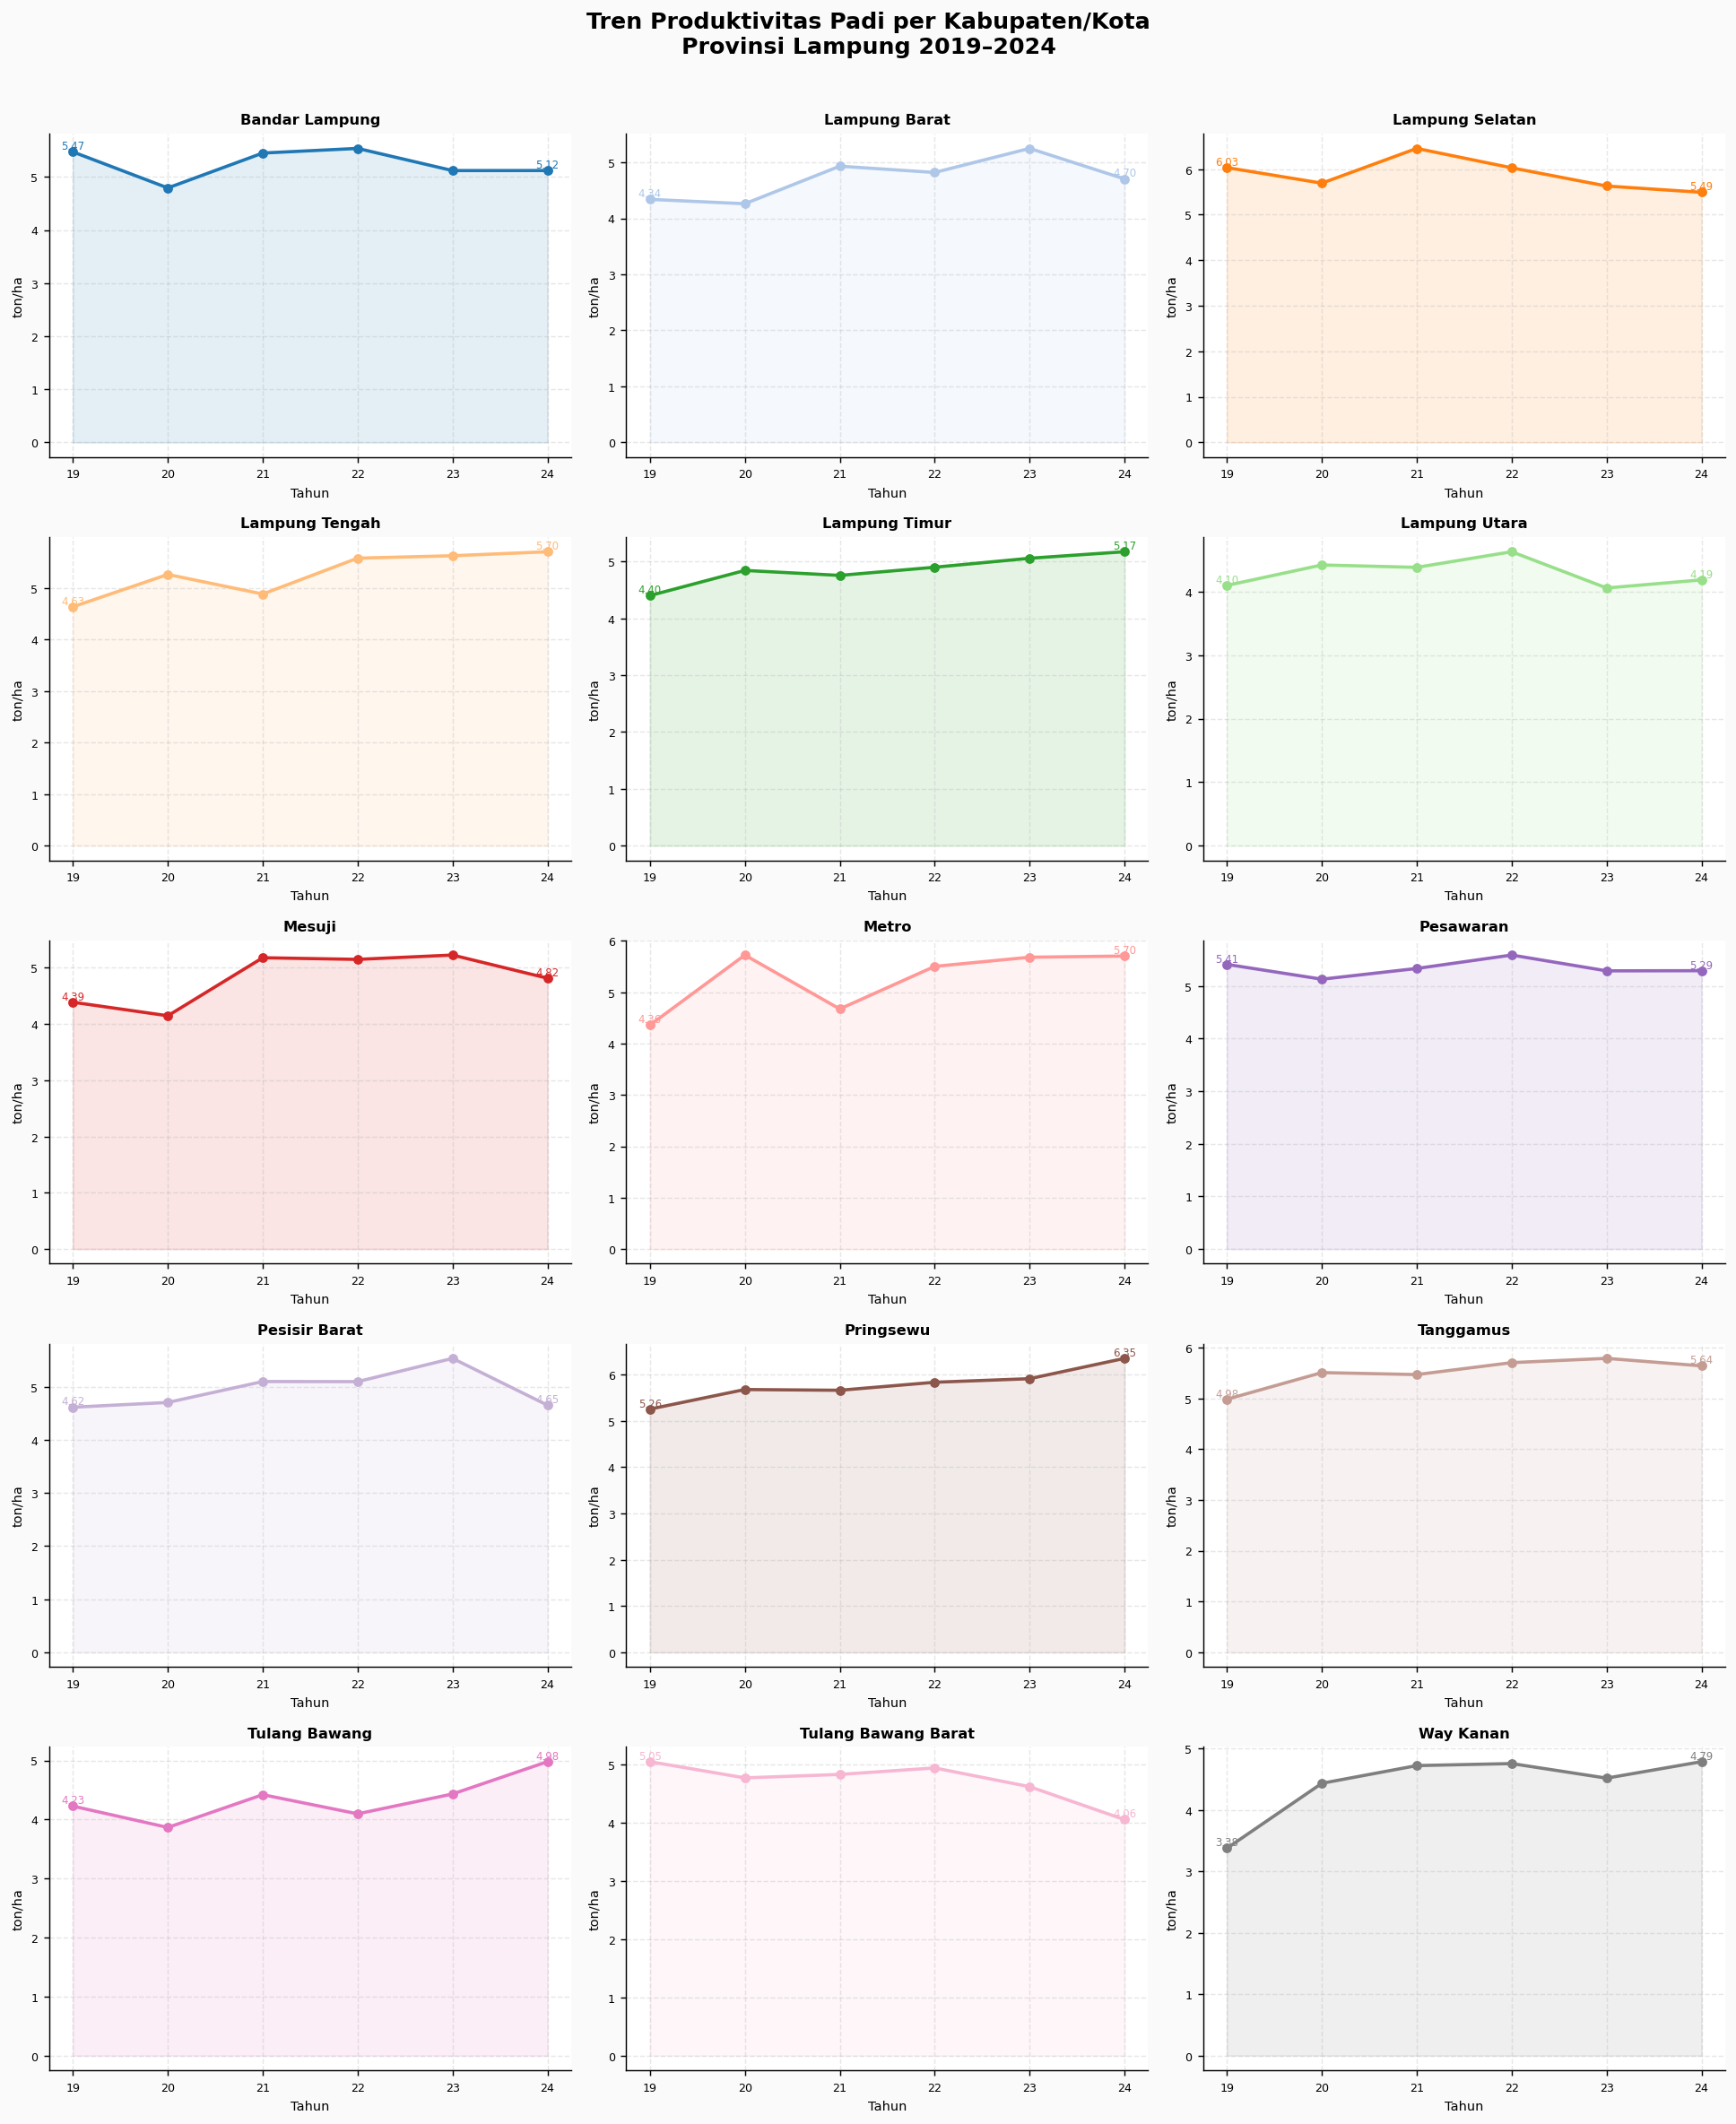

In [14]:
kabupaten_list = sorted(df_fitur['kabupaten'].unique())
n_kab = len(kabupaten_list)
ncols, nrows = 3, 5

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 18))
fig.suptitle('Tren Produktivitas Padi per Kabupaten/Kota\nProvinsi Lampung 2019–2024',
             fontsize=14, fontweight='bold', y=1.01)
fig.patch.set_facecolor('#fafafa')

for idx, kab in enumerate(kabupaten_list):
    ax    = axes[idx // ncols][idx % ncols]
    df_k  = df_fitur[df_fitur['kabupaten'] == kab].sort_values('tahun')
    color = PALETTE_KAB[idx % len(PALETTE_KAB)]
    ax.plot(df_k['tahun'], df_k['produktivitas_ton_per_ha'],
            marker='o', linewidth=2, markersize=5, color=color)
    ax.fill_between(df_k['tahun'], df_k['produktivitas_ton_per_ha'],
                    alpha=0.12, color=color)
    ax.set_title(kab, fontsize=9, fontweight='bold')
    # Annotasi nilai awal dan akhir
    if len(df_k) >= 2:
        ax.annotate(f"{df_k['produktivitas_ton_per_ha'].iloc[0]:.2f}",
                    xy=(df_k['tahun'].iloc[0], df_k['produktivitas_ton_per_ha'].iloc[0]),
                    fontsize=6.5, ha='center', va='bottom', color=color)
        ax.annotate(f"{df_k['produktivitas_ton_per_ha'].iloc[-1]:.2f}",
                    xy=(df_k['tahun'].iloc[-1], df_k['produktivitas_ton_per_ha'].iloc[-1]),
                    fontsize=6.5, ha='center', va='bottom', color=color)
    ax.set_xlabel('Tahun', fontsize=8)
    ax.set_ylabel('ton/ha', fontsize=8)
    ax.set_xticks(TAHUN_FITUR)
    ax.set_xticklabels([str(t)[2:] for t in TAHUN_FITUR], fontsize=7)
    ax.tick_params(axis='y', labelsize=7)

for i in range(n_kab, nrows * ncols):
    axes[i // ncols][i % ncols].set_visible(False)

plt.tight_layout()
save_figure('tren_produktivitas.png')
plt.show()


## 3.3 Distribusi Produktivitas

Visualisasi distribusi membantu menilai seberapa bervariasi produktivitas antar
kabupaten dan apakah terdapat outlier atau pola asimetri yang perlu diperhatikan.

- **Histogram** (kiri): distribusi keseluruhan 90 sampel; garis merah = rata-rata, oranye = ±1 standar deviasi
- **Boxplot** (kanan): distribusi per kabupaten, diurutkan dari median tertinggi


/tmp/ipykernel_700/3896589775.py:23: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(df_box, vert=False, patch_artist=True,
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[SAVED] results/Images/distribusi_produktivitas.png


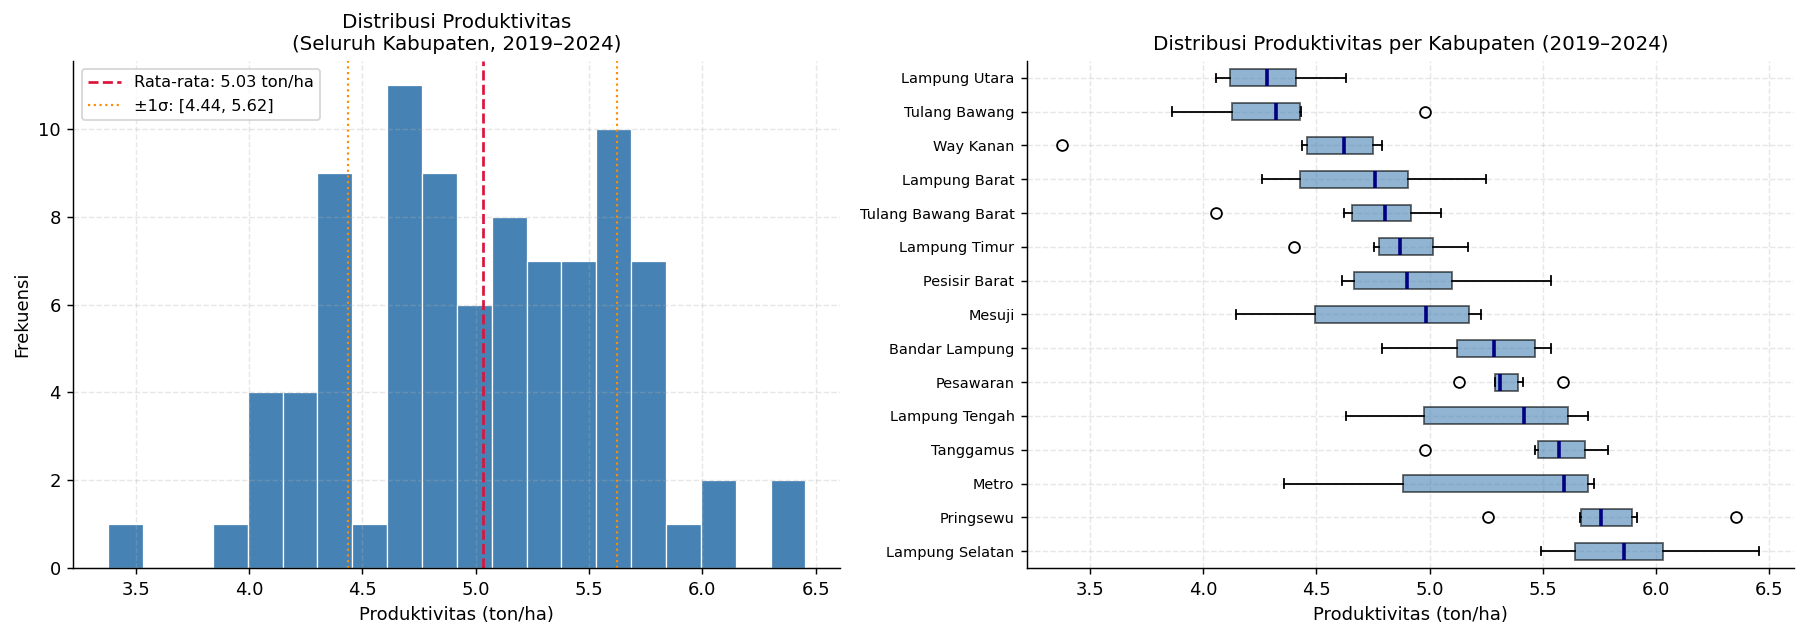

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram seluruh sampel
ax   = axes[0]
vals = df_fitur['produktivitas_ton_per_ha']
ax.hist(vals, bins=20, color='steelblue', edgecolor='white', linewidth=0.7)
ax.axvline(vals.mean(), color='crimson', linestyle='--', linewidth=1.5,
           label=f'Rata-rata: {vals.mean():.2f} ton/ha')
ax.axvline(vals.mean() - vals.std(), color='darkorange', linestyle=':', linewidth=1.2,
           label=f'±1σ: [{vals.mean()-vals.std():.2f}, {vals.mean()+vals.std():.2f}]')
ax.axvline(vals.mean() + vals.std(), color='darkorange', linestyle=':', linewidth=1.2)
ax.set_title('Distribusi Produktivitas\n(Seluruh Kabupaten, 2019–2024)', fontsize=11)
ax.set_xlabel('Produktivitas (ton/ha)')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=9)

# Boxplot per kabupaten
ax           = axes[1]
median_order = (df_fitur.groupby('kabupaten')['produktivitas_ton_per_ha']
                .median().sort_values(ascending=False).index)
df_box = [df_fitur[df_fitur['kabupaten'] == k]['produktivitas_ton_per_ha'].values
          for k in median_order]
bp = ax.boxplot(df_box, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='navy', linewidth=2))
ax.set_yticks(range(1, len(median_order) + 1))
ax.set_yticklabels(median_order, fontsize=8)
ax.set_title('Distribusi Produktivitas per Kabupaten (2019–2024)', fontsize=11)
ax.set_xlabel('Produktivitas (ton/ha)')

plt.tight_layout()
save_figure('distribusi_produktivitas.png')
plt.show()


## 3.4 Pola Cuaca per Musim Tanam

Grafik berikut menampilkan rata-rata setiap parameter cuaca untuk masing-masing musim tanam
dari tahun ke tahun. Perbedaan antar musim mencerminkan kontras iklim yang cukup signifikan
di Lampung — dari musim penghujan (Utama) hingga musim kemarau.

Pola cuaca yang konsisten dari tahun ke tahun menunjukkan bahwa informasi musiman
dapat menjadi sinyal prediktif yang berguna untuk model.


[SAVED] results/Images/cuaca_musiman.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


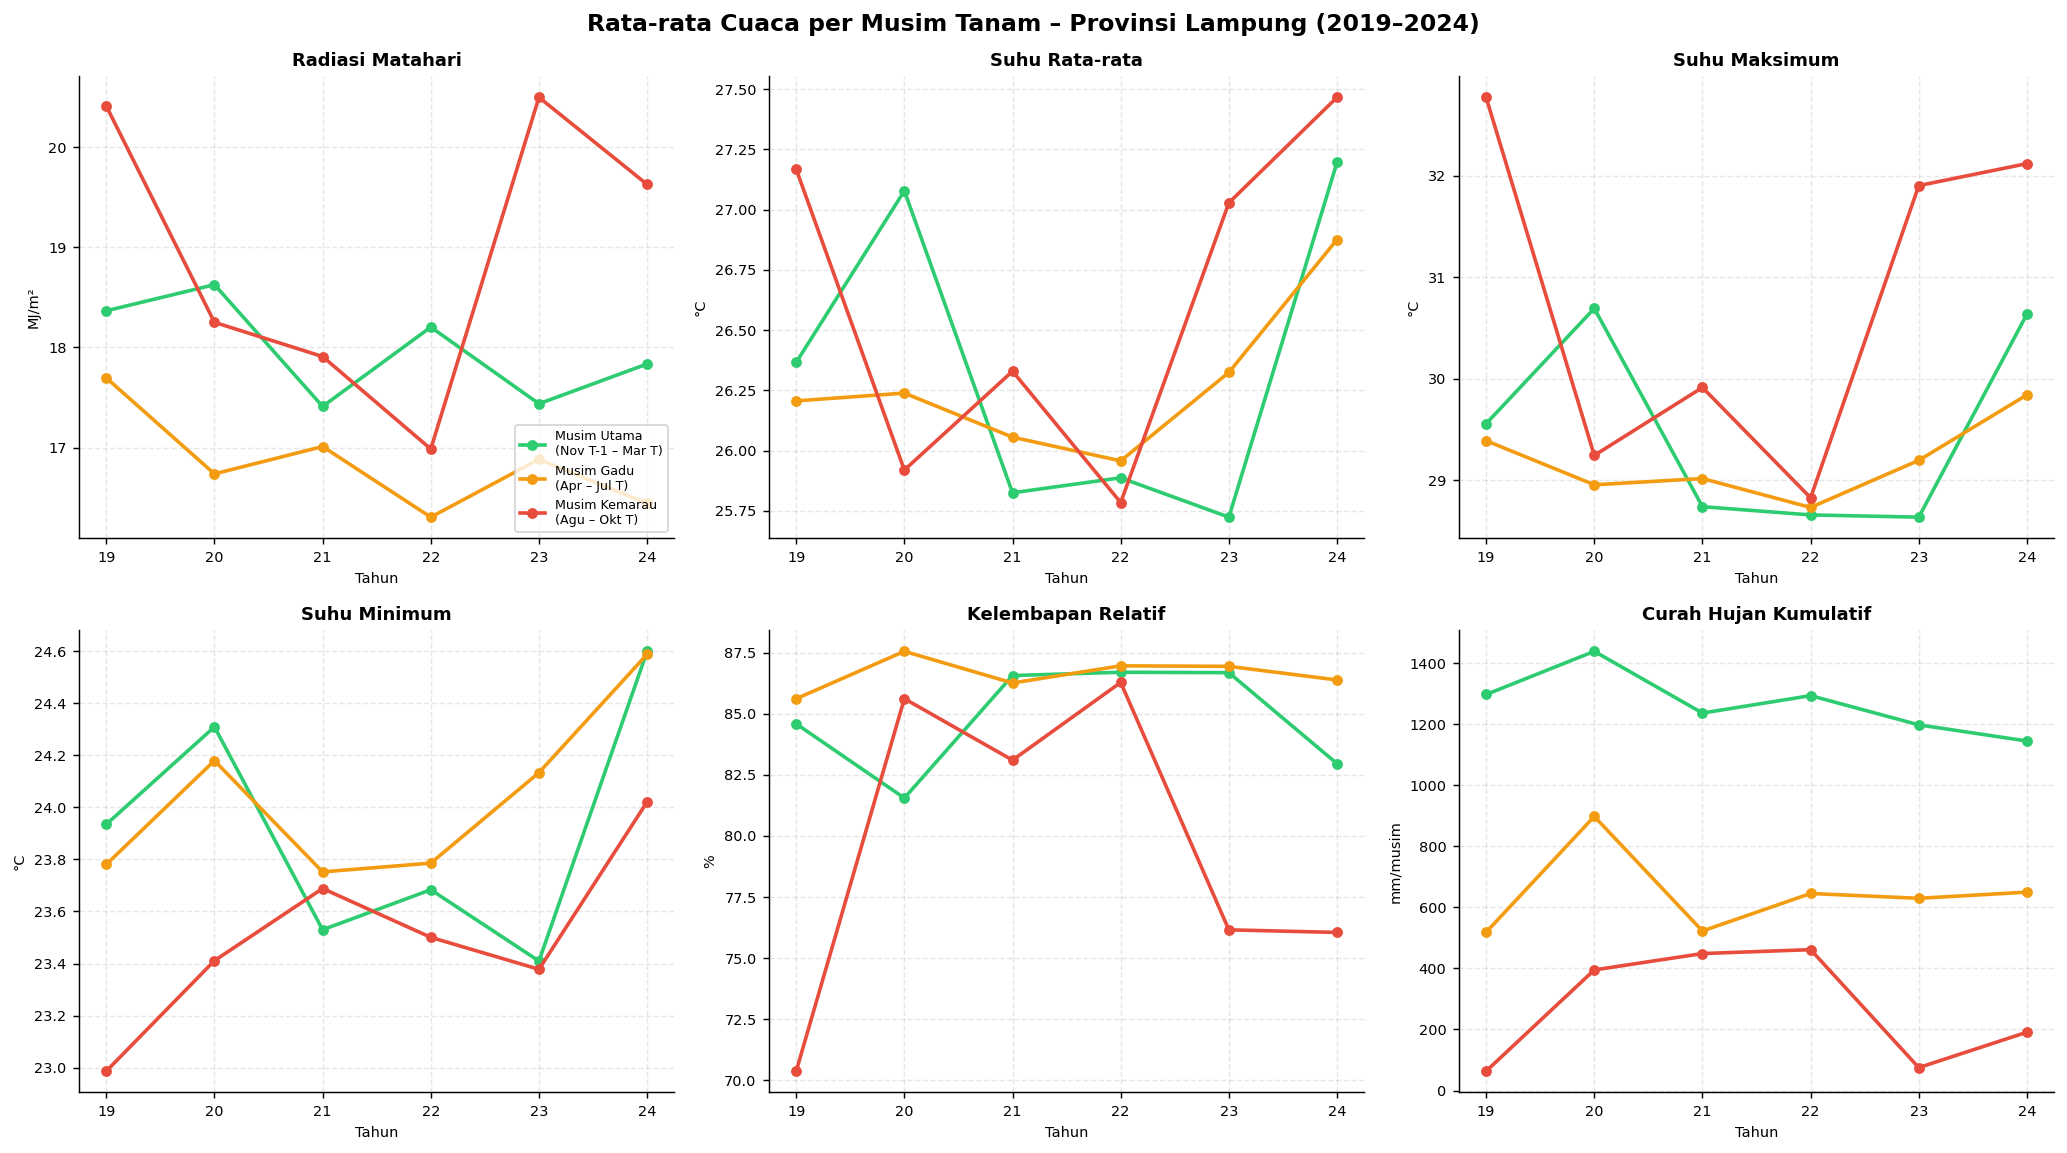

In [16]:
musim_label = {
    'utama'  : 'Musim Utama\n(Nov T-1 – Mar T)',
    'gadu'   : 'Musim Gadu\n(Apr – Jul T)',
    'kemarau': 'Musim Kemarau\n(Agu – Okt T)',
}
musim_warna = {'utama': '#2ecc71', 'gadu': '#f39c12', 'kemarau': '#e74c3c'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Rata-rata Cuaca per Musim Tanam – Provinsi Lampung (2019–2024)',
             fontsize=13, fontweight='bold')

param_plot = [
    ('ALLSKY_SFC_SW_DWN', 'Radiasi Matahari',      'MJ/m²'),
    ('T2M',               'Suhu Rata-rata',         '°C'),
    ('T2M_MAX',           'Suhu Maksimum',          '°C'),
    ('T2M_MIN',           'Suhu Minimum',           '°C'),
    ('RH2M',              'Kelembapan Relatif',     '%'),
    ('PRECTOTCORR',       'Curah Hujan Kumulatif',  'mm/musim'),
]

for idx, (param, label, unit) in enumerate(param_plot):
    ax = axes[idx // 3][idx % 3]
    for musim in ['utama', 'gadu', 'kemarau']:
        suffix = 'sum' if param == 'PRECTOTCORR' else 'mean'
        col = f'{param}_{musim}_{suffix}'
        if col not in df_fitur.columns:
            continue
        val = df_fitur.groupby('tahun')[col].mean()
        ax.plot(val.index, val.values, marker='o', linewidth=2,
                color=musim_warna[musim], label=musim_label[musim], markersize=5)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel(unit, fontsize=8)
    ax.set_xlabel('Tahun', fontsize=8)
    ax.set_xticks(TAHUN_FITUR)
    ax.set_xticklabels([str(t)[2:] for t in TAHUN_FITUR], fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    if idx == 0:
        ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
save_figure('cuaca_musiman.png')
plt.show()


## 3.5 Korelasi Fitur Cuaca Musiman dengan Produktivitas

Korelasi Pearson dihitung antara masing-masing fitur cuaca musiman dan target
produktivitas (ton/ha). Karena target sudah dinormalisasi per hektar, korelasi
mencerminkan hubungan agronomis yang lebih murni, bebas dari efek perbedaan
ukuran lahan antar kabupaten.

**Cara membaca grafik:**
- Korelasi positif (biru) berarti semakin tinggi nilai fitur, produktivitas cenderung meningkat
- Korelasi negatif (merah) berarti hubungan berlawanan arah
- Nilai mendekati ±1 menunjukkan hubungan yang kuat


[SAVED] results/Images/korelasi_fitur.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


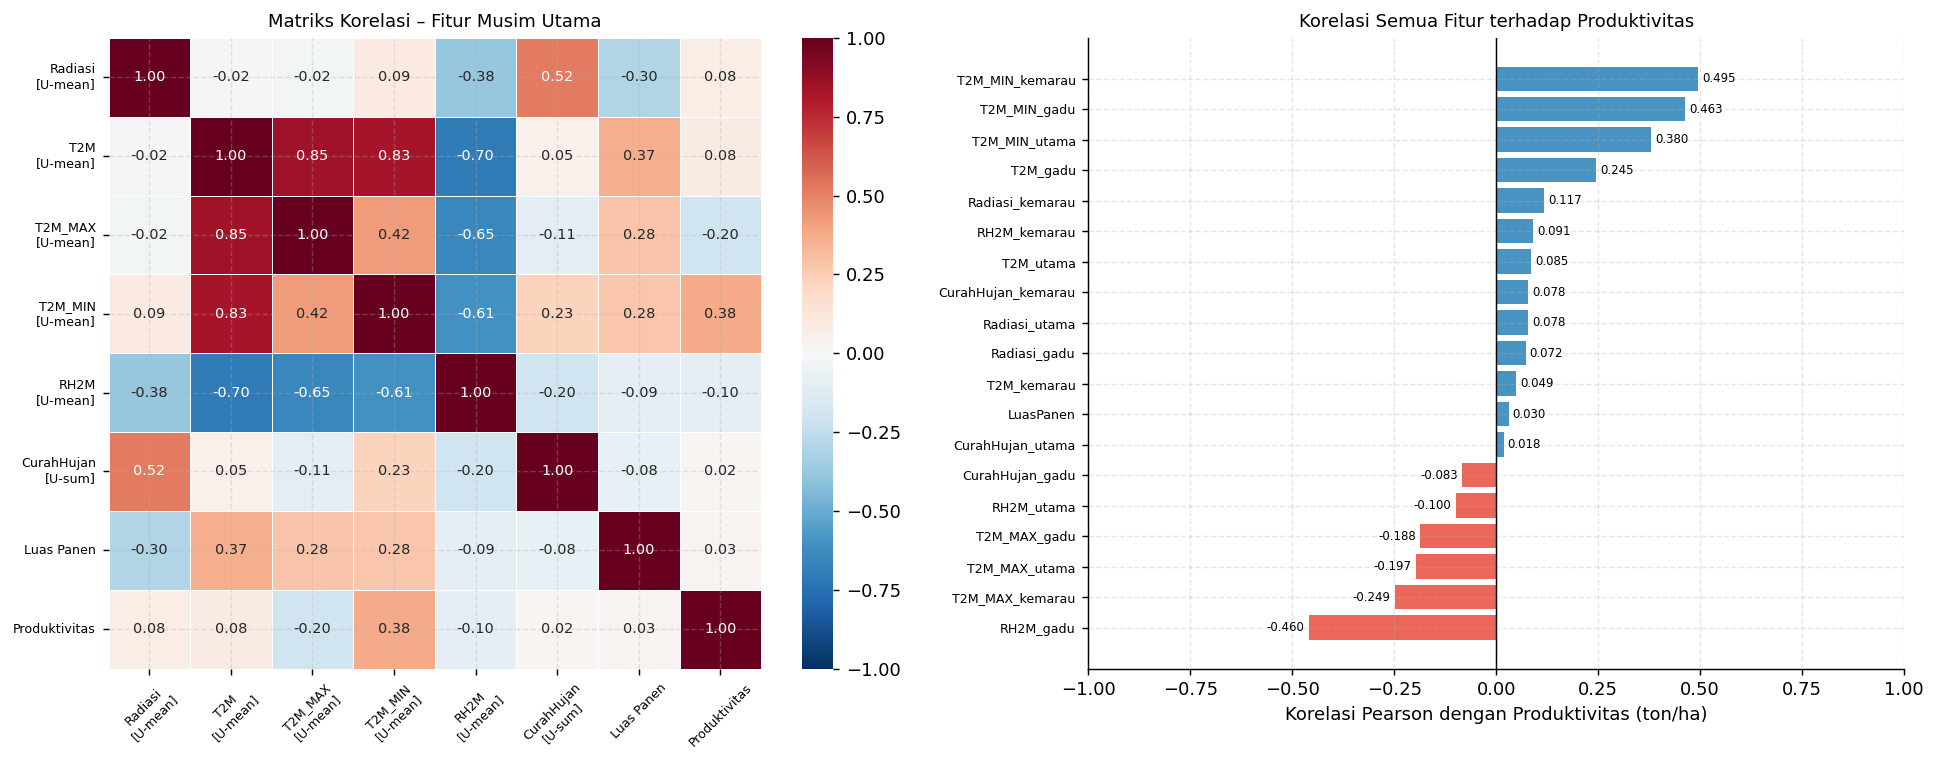

In [17]:
korel        = df_fitur[KOLOM_CUACA + ['luas_panen_ha', 'produktivitas_ton_per_ha']].corr()
korel_target = korel['produktivitas_ton_per_ha'].drop('produktivitas_ton_per_ha').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap korelasi fitur Musim Utama
param_cols = [c for c in KOLOM_CUACA if 'utama' in c] + ['luas_panen_ha', 'produktivitas_ton_per_ha']
korel_sub  = df_fitur[param_cols].corr()
label_sub  = [c.replace('_utama_mean', '\n[U-mean]')
               .replace('_utama_sum',  '\n[U-sum]')
               .replace('ALLSKY_SFC_SW_DWN', 'Radiasi')
               .replace('PRECTOTCORR', 'CurahHujan')
               .replace('produktivitas_ton_per_ha', 'Produktivitas')
               .replace('luas_panen_ha', 'Luas Panen')
              for c in param_cols]
sns.heatmap(korel_sub, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=label_sub, yticklabels=label_sub, ax=axes[0],
            annot_kws={'size': 8}, vmin=-1, vmax=1, linewidths=0.3)
axes[0].set_title('Matriks Korelasi – Fitur Musim Utama', fontsize=10)
axes[0].tick_params(axis='x', labelsize=7, rotation=45)
axes[0].tick_params(axis='y', labelsize=7, rotation=0)

# Bar chart korelasi semua fitur
colors_bar = ['#e74c3c' if v < 0 else '#2980b9' for v in korel_target.values]
bars       = axes[1].barh(range(len(korel_target)), korel_target.values,
                          color=colors_bar, alpha=0.85)
axes[1].set_yticks(range(len(korel_target)))
axes[1].set_yticklabels(
    [c.replace('_mean', '').replace('_sum', '')
      .replace('ALLSKY_SFC_SW_DWN', 'Radiasi')
      .replace('PRECTOTCORR', 'CurahHujan')
      .replace('luas_panen_ha', 'LuasPanen')
     for c in korel_target.index],
    fontsize=7
)
for bar, val in zip(bars, korel_target.values):
    axes[1].text(val + (0.01 if val >= 0 else -0.01),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=6.5)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Korelasi Pearson dengan Produktivitas (ton/ha)')
axes[1].set_title('Korelasi Semua Fitur terhadap Produktivitas', fontsize=10)
axes[1].set_xlim(-1, 1)

plt.tight_layout()
save_figure('korelasi_fitur.png')
plt.show()


---

# 4. Pemodelan dan Evaluasi

## 4.1 Konfigurasi Model

Penelitian ini membandingkan tiga model Machine Learning dan empat model baseline.
Perbandingan dengan baseline sangat penting untuk menilai apakah kompleksitas ML
benar-benar memberikan nilai tambah.

### Model Machine Learning

| Model | Alasan Pemilihan |
|---|---|
| **Ridge Regression** | Regresi linear dengan regularisasi L2; efektif pada rasio sampel/fitur rendah |
| **Ridge Hist Lag** | Ridge hanya dengan fitur historis produktivitas; lebih hemat fitur |
| **Random Forest** | Ensemble pohon keputusan; robust terhadap dataset kecil |
| **Gradient Boosting** | Umumnya terbaik untuk data tabular; diregularisasi untuk menghindari overfitting |

### Model Baseline (Acuan Minimum)

Setiap model ML **harus** melampaui baseline agar dianggap memberikan nilai prediktif nyata.

| Baseline | Deskripsi | Catatan |
|---|---|---|
| **Naive Mean** | Prediksi = rata-rata seluruh training | Batas bawah tanpa informasi lokasi |
| **Naive Kab Mean** | Prediksi = rata-rata historis per kabupaten | Baseline lokasi |
| **Naive Lag1** | Prediksi = produktivitas tahun sebelumnya | Baseline temporal kuat |
| **Naive Roll2** | Prediksi = rata-rata dua tahun terakhir | Baseline temporal halus |

> **Mengapa baseline penting?** Target produktivitas memiliki koefisien variasi hanya ~9%.
> Prediksi naif "selalu rata-rata" sudah menghasilkan MAPE sekitar 9% tanpa belajar apapun.
> Model ML baru bermakna jika MAPE-nya jauh lebih rendah dari angka ini.


In [18]:
# ── Model ML ─────────────────────────────────────────────────────────────────
MODELDEFS = {
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=10.0)),
    ]),
    'Ridge Hist Lag': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=3.0)),
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators     = 300,
        max_depth        = 5,
        min_samples_leaf = 3,
        max_features     = 'sqrt',
        random_state     = RANDOM_STATE,
        n_jobs           = -1,
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators     = 150,
        max_depth        = 3,
        learning_rate    = 0.08,
        subsample        = 0.8,
        min_samples_leaf = 3,
        random_state     = RANDOM_STATE,
    ),
}

# ── Model Baseline ────────────────────────────────────────────────────────────
class NaiveMeanRegressor:
    """Prediksi selalu rata-rata target dari data training."""
    def fit(self, X, y, **kw):
        self.mean_ = float(np.mean(y))
        return self
    def predict(self, X):
        return np.full(len(X), self.mean_)

class NaiveKabMeanRegressor:
    """Prediksi rata-rata historis per kabupaten dari data training."""
    def fit(self, X_meta, y, **kw):
        # X_meta: DataFrame dengan kolom 'kabupaten' dan 'produktivitas_ton_per_ha'
        self.kab_mean_  = X_meta.groupby('kabupaten')['produktivitas_ton_per_ha'].mean()
        self.global_mean_ = float(np.mean(y))
        return self
    def predict(self, X_meta):
        return (X_meta['kabupaten']
                .map(self.kab_mean_)
                .fillna(self.global_mean_)
                .values)

class NaiveLag1Regressor:
    """Baseline temporal: prediksi produktivitas = produktivitas tahun sebelumnya."""
    def fit(self, X_meta, y=None, **kw):
        return self
    def predict(self, X_meta):
        return X_meta['prodvt_lag1'].values

class NaiveRoll2Regressor:
    """Baseline temporal: prediksi = rata-rata produktivitas dua tahun terakhir."""
    def fit(self, X_meta, y=None, **kw):
        return self
    def predict(self, X_meta):
        return X_meta['prodvt_roll2'].values

MODEL_FEATURES = {name: FITUR_MODEL for name in MODELDEFS}
MODEL_FEATURES['Ridge Hist Lag'] = FITUR_HIST

BASELINEDEFS = {
    'Naive Mean'    : NaiveMeanRegressor(),
    'Naive Kab Mean': NaiveKabMeanRegressor(),
    'Naive Lag1'    : NaiveLag1Regressor(),
    'Naive Roll2'   : NaiveRoll2Regressor(),
}

SEMUA_MODEL = list(MODELDEFS.keys()) + list(BASELINEDEFS.keys())

print("Konfigurasi model ML:")
for name, mdl in MODELDEFS.items():
    if hasattr(mdl, 'steps'):
        params = mdl.named_steps['model'].get_params()
    else:
        params = {k: v for k, v in mdl.get_params().items()
                  if k in ('n_estimators', 'max_depth', 'learning_rate',
                            'subsample', 'alpha', 'min_samples_leaf')}
    print(f"  {name}: {params}")
print()
print("Baseline model: Naive Mean, Naive Kab Mean, Naive Lag1, Naive Roll2")


Konfigurasi model ML:
  Ridge Regression: {'alpha': 10.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
  Ridge Hist Lag: {'alpha': 3.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
  Random Forest: {'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 300}
  Gradient Boosting: {'alpha': 0.9, 'learning_rate': 0.08, 'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 150, 'subsample': 0.8}

Baseline model: Naive Mean, Naive Kab Mean, Naive Lag1, Naive Roll2


## 4.2 Walk-Forward Validation

### Mengapa Walk-Forward Validation?

Prediksi produktivitas padi bersifat **temporal**: model dilatih pada data masa lalu
dan diuji pada data masa depan. Metode evaluasi yang tidak menghormati urutan waktu
akan menghasilkan estimasi performa yang terlalu optimis (*temporal leakage*).

Pada versi sebelumnya (LOYOCV), terdapat masalah serius: fold pertama menguji tahun 2019
tetapi dilatih menggunakan data tahun 2020–2024 — data yang secara kronologis belum ada
saat prediksi dibuat. Ini adalah bentuk *data leakage* yang harus dihindari.

**Walk-Forward Validation** memastikan setiap fold hanya menggunakan data masa lalu:

```
Fold 1: Train [2019]           → Test 2020  (15 sampel train, 15 sampel test)
Fold 2: Train [2019–2020]      → Test 2021  (30 sampel train, 15 sampel test)
Fold 3: Train [2019–2021]      → Test 2022  (45 sampel train, 15 sampel test)
Fold 4: Train [2019–2022]      → Test 2023  (60 sampel train, 15 sampel test)
Fold 5: Train [2019–2023]      → Test 2024  (75 sampel train, 15 sampel test)
```

> **Catatan fold awal:** Fold 1 hanya memiliki 15 sampel training untuk ~33 fitur.
> Ridge Regression (regularisasi kuat) lebih stabil pada kondisi ini dibanding
> Random Forest atau Gradient Boosting.


In [19]:
def hitung_mape(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

# Struktur penyimpanan hasil
WFV_HASIL = {
    nm: {'rmse': [], 'mae': [], 'r2': [], 'mape': [],
         'tahun': [], 'y_true': [], 'y_pred': []}
    for nm in SEMUA_MODEL
}

TAHUN_TEST_WFV = TAHUN_FITUR[1:]   # test mulai 2020 (butuh ≥1 tahun training)

print("Walk-Forward Validation")
print("=" * 65)

for tahun_test in TAHUN_TEST_WFV:
    train_mask = df_fitur['tahun'] < tahun_test
    test_mask  = df_fitur['tahun'] == tahun_test

    y_tr = df_model[train_mask]['produktivitas_ton_per_ha'].values
    y_te = df_model[test_mask]['produktivitas_ton_per_ha'].values

    meta_tr = df_fitur[train_mask]
    meta_te = df_fitur[test_mask]

    tahun_train_str = (f"{TAHUN_FITUR[0]}–{tahun_test-1}"
                       if tahun_test - 1 > TAHUN_FITUR[0]
                       else str(TAHUN_FITUR[0]))
    print(f"  Fold {tahun_test} | Train: {tahun_train_str} "
          f"({len(y_tr):>2} sampel) | Test: {tahun_test} (15 sampel)")

    # ── Model ML ──────────────────────────────────────────────────────────────
    for name, mdl_def in MODELDEFS.items():
        fitur_cols = MODEL_FEATURES[name]
        X_tr = df_model.loc[train_mask, fitur_cols].values.astype(float)
        X_te = df_model.loc[test_mask, fitur_cols].values.astype(float)

        m    = copy.deepcopy(mdl_def)
        m.fit(X_tr, y_tr)
        y_pr = np.clip(m.predict(X_te), 0, None)

        WFV_HASIL[name]['rmse'].append(np.sqrt(mean_squared_error(y_te, y_pr)))
        WFV_HASIL[name]['mae'].append(mean_absolute_error(y_te, y_pr))
        WFV_HASIL[name]['r2'].append(r2_score(y_te, y_pr))
        WFV_HASIL[name]['mape'].append(hitung_mape(y_te, y_pr))
        WFV_HASIL[name]['tahun'].append(tahun_test)
        WFV_HASIL[name]['y_true'].extend(y_te.tolist())
        WFV_HASIL[name]['y_pred'].extend(y_pr.tolist())

    # ── Baseline ──────────────────────────────────────────────────────────────
    for name, baseline_def in BASELINEDEFS.items():
        b = copy.deepcopy(baseline_def)
        b.fit(meta_tr, y_tr)
        y_pr_base = b.predict(meta_te)
        WFV_HASIL[name]['rmse'].append(np.sqrt(mean_squared_error(y_te, y_pr_base)))
        WFV_HASIL[name]['mae'].append(mean_absolute_error(y_te, y_pr_base))
        WFV_HASIL[name]['r2'].append(r2_score(y_te, y_pr_base))
        WFV_HASIL[name]['mape'].append(hitung_mape(y_te, y_pr_base))
        WFV_HASIL[name]['tahun'].append(tahun_test)
        WFV_HASIL[name]['y_true'].extend(y_te.tolist())
        WFV_HASIL[name]['y_pred'].extend(y_pr_base.tolist())

print()
print("Selesai.")


Walk-Forward Validation
  Fold 2020 | Train: 2019 (15 sampel) | Test: 2020 (15 sampel)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Fold 2021 | Train: 2019–2020 (30 sampel) | Test: 2021 (15 sampel)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  Fold 2022 | Train: 2019–2021 (45 sampel) | Test: 2022 (15 sampel)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  Fold 2024 | Train: 2019–2023 (75 sampel) | Test: 2024 (15 sampel)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Selesai.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 4.3 Perbandingan Performa Model

Tabel berikut merangkum performa semua model (ML dan baseline) berdasarkan rata-rata
5 fold Walk-Forward Validation (2020–2024).

**Metrik yang digunakan:**
- **MAPE** (Mean Absolute Percentage Error): persentase rata-rata selisih antara prediksi dan nilai aktual — metrik utama
- **RMSE** (Root Mean Squared Error): dalam satuan ton/ha
- **MAE** (Mean Absolute Error): rata-rata selisih absolut dalam ton/ha
- **R²** (Koefisien Determinasi): proporsi variasi yang dijelaskan model (0–1, semakin tinggi semakin baik)

> Model diurutkan dari MAPE terkecil (terbaik) ke MAPE terbesar.


In [20]:
# Tabel ringkasan
rows_cv = []
for name in SEMUA_MODEL:
    h = WFV_HASIL[name]
    rows_cv.append({
        'Model'         : name,
        'RMSE mean'     : np.mean(h['rmse']),
        'RMSE std'      : np.std(h['rmse']),
        'MAE mean'      : np.mean(h['mae']),
        'R2 mean'       : np.mean(h['r2']),
        'MAPE mean (%)' : np.mean(h['mape']),
        'MAPE std (%)'  : np.std(h['mape']),
    })

df_cv_summary = (pd.DataFrame(rows_cv)
                 .set_index('Model')
                 .sort_values('MAPE mean (%)'))

# ── Hitung variabel kunci SEBELUM digunakan di label_model ──────────────────
mape_naive_mean = df_cv_summary.loc['Naive Mean', 'MAPE mean (%)']
mape_naive_kab  = df_cv_summary.loc['Naive Kab Mean', 'MAPE mean (%)']
baseline_models = list(BASELINEDEFS.keys())
BEST_BASELINE_WFV   = df_cv_summary.loc[baseline_models, 'MAPE mean (%)'].idxmin()
mape_best_baseline  = df_cv_summary.loc[BEST_BASELINE_WFV, 'MAPE mean (%)']

ml_models_only    = df_cv_summary.loc[list(MODELDEFS.keys())]
MODEL_TERBAIK     = ml_models_only['MAPE mean (%)'].idxmin()
MODEL_ML_TERBAIK  = MODEL_TERBAIK
MODEL_OVERALL_TERBAIK = df_cv_summary['MAPE mean (%)'].idxmin()
mape_terbaik      = ml_models_only.loc[MODEL_ML_TERBAIK, 'MAPE mean (%)']
mape_overall      = df_cv_summary.loc[MODEL_OVERALL_TERBAIK, 'MAPE mean (%)']

# ── Beri label pada setiap model ────────────────────────────────────────────
from IPython.display import display

label_model = {}
for nm in df_cv_summary.index:
    if nm == MODEL_OVERALL_TERBAIK and nm == MODEL_ML_TERBAIK:
        label_model[nm] = "Terbaik ML & Overall"
    elif nm == MODEL_OVERALL_TERBAIK:
        label_model[nm] = "Terbaik Overall"
    elif nm == MODEL_ML_TERBAIK:
        label_model[nm] = "Terbaik ML"
    elif nm == BEST_BASELINE_WFV:
        label_model[nm] = "Baseline Terbaik"
    elif nm.startswith('Naive'):
        label_model[nm] = "Baseline"
    else:
        label_model[nm] = "Model ML"

df_cv_display = df_cv_summary.copy().round(4)
df_cv_display.insert(0, 'Label', [label_model[nm] for nm in df_cv_display.index])

def highlight_model(row):
    lbl = row['Label']
    if 'Terbaik ML' in lbl and 'Overall' in lbl:
        return ['background-color: #d4edda; font-weight: bold'] * len(row)
    elif 'Terbaik ML' in lbl:
        return ['background-color: #d4edda; font-weight: bold'] * len(row)
    elif 'Terbaik Overall' in lbl:
        return ['background-color: #cce5ff; font-weight: bold'] * len(row)
    elif 'Baseline Terbaik' in lbl:
        return ['background-color: #fff3cd'] * len(row)
    elif lbl == 'Baseline':
        return ['color: #6c757d'] * len(row)
    return [''] * len(row)

display(
    df_cv_display.style
    .apply(highlight_model, axis=1)
    .format({
        'RMSE mean': '{:.4f}', 'RMSE std': '{:.4f}',
        'MAE mean': '{:.4f}', 'R2 mean': '{:.4f}',
        'MAPE mean (%)': '{:.2f}%', 'MAPE std (%)': '{:.2f}%',
    })
    .set_caption("Perbandingan Model – Walk-Forward Validation 5 Fold (2020–2024) | Diurutkan MAPE terkecil")
)
print()

# ── Ringkasan teks ───────────────────────────────────────────────────────────
print(f"Referensi Baseline:")
print(f"  Naive Mean      : MAPE = {mape_naive_mean:.2f}%  (batas bawah tanpa informasi lokasi)")
print(f"  Naive Kab Mean  : MAPE = {mape_naive_kab:.2f}%  (baseline historis per kabupaten)")
print(f"  Baseline Terbaik: {BEST_BASELINE_WFV} – MAPE = {mape_best_baseline:.2f}%")
print()
print(f"Model ML Terbaik   : {MODEL_ML_TERBAIK}  (MAPE = {mape_terbaik:.2f}%)")
print(f"Model Overall Terbaik: {MODEL_OVERALL_TERBAIK}  (MAPE = {mape_overall:.2f}%)")
print()
print("--- Analisis Komparatif ---")
if mape_terbaik < mape_naive_kab:
    selisih_kab = mape_naive_kab - mape_terbaik
    print(f"Model ML ({MODEL_ML_TERBAIK}) unggul {selisih_kab:.2f} poin MAPE di atas Naive Kab Mean.")
else:
    selisih_kab = mape_terbaik - mape_naive_kab
    print(f"Catatan: Model ML masih kalah {selisih_kab:.2f} poin MAPE dari Naive Kab Mean.")
    print("  Ini mengindikasikan baseline lokasi historis sangat kuat pada dataset kecil ini.")

if mape_terbaik < mape_best_baseline:
    selisih_base = mape_best_baseline - mape_terbaik
    print(f"Model ML juga unggul {selisih_base:.2f} poin MAPE di atas baseline temporal terbaik ({BEST_BASELINE_WFV}).")
else:
    selisih_base = mape_terbaik - mape_best_baseline
    print(f"Batasan penelitian: Model ML belum mengalahkan baseline temporal terbaik ({BEST_BASELINE_WFV}).")
    print(f"  Selisih: {selisih_base:.2f} poin MAPE. Ini konsisten dengan keterbatasan ukuran dataset (90 sampel).")


,Label,RMSE mean,RMSE std,MAE mean,R2 mean,MAPE mean (%),MAPE std (%)
Model,,,,,,,
Naive Roll2,Terbaik Overall,0.3929,0.0767,0.3301,0.4700,6.59%,1.35%
Ridge Hist Lag,Terbaik ML,0.4277,0.0748,0.3478,0.3693,6.75%,1.12%
Naive Lag1,Baseline,0.4315,0.1085,0.3389,0.3394,6.76%,1.82%
Naive Kab Mean,Baseline,0.4545,0.0670,0.3817,0.3019,7.48%,1.09%
Ridge Regression,Model ML,0.4904,0.1361,0.4178,0.1181,8.14%,2.59%
Random Forest,Model ML,0.5386,0.0268,0.4263,0.0193,8.17%,0.43%
Gradient Boosting,Model ML,0.5241,0.1082,0.4399,0.0193,8.54%,1.99%
Naive Mean,Baseline,0.5943,0.0106,0.4807,-0.1943,9.26%,0.80%



Referensi Baseline:
  Naive Mean      : MAPE = 9.26%  (batas bawah tanpa informasi lokasi)
  Naive Kab Mean  : MAPE = 7.48%  (baseline historis per kabupaten)
  Baseline Terbaik: Naive Roll2 – MAPE = 6.59%

Model ML Terbaik   : Ridge Hist Lag  (MAPE = 6.75%)
Model Overall Terbaik: Naive Roll2  (MAPE = 6.59%)

--- Analisis Komparatif ---
Model ML (Ridge Hist Lag) unggul 0.72 poin MAPE di atas Naive Kab Mean.
Batasan penelitian: Model ML belum mengalahkan baseline temporal terbaik (Naive Roll2).
  Selisih: 0.17 poin MAPE. Ini konsisten dengan keterbatasan ukuran dataset (90 sampel).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[SAVED] results/Images/perbandingan_model_wfv.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


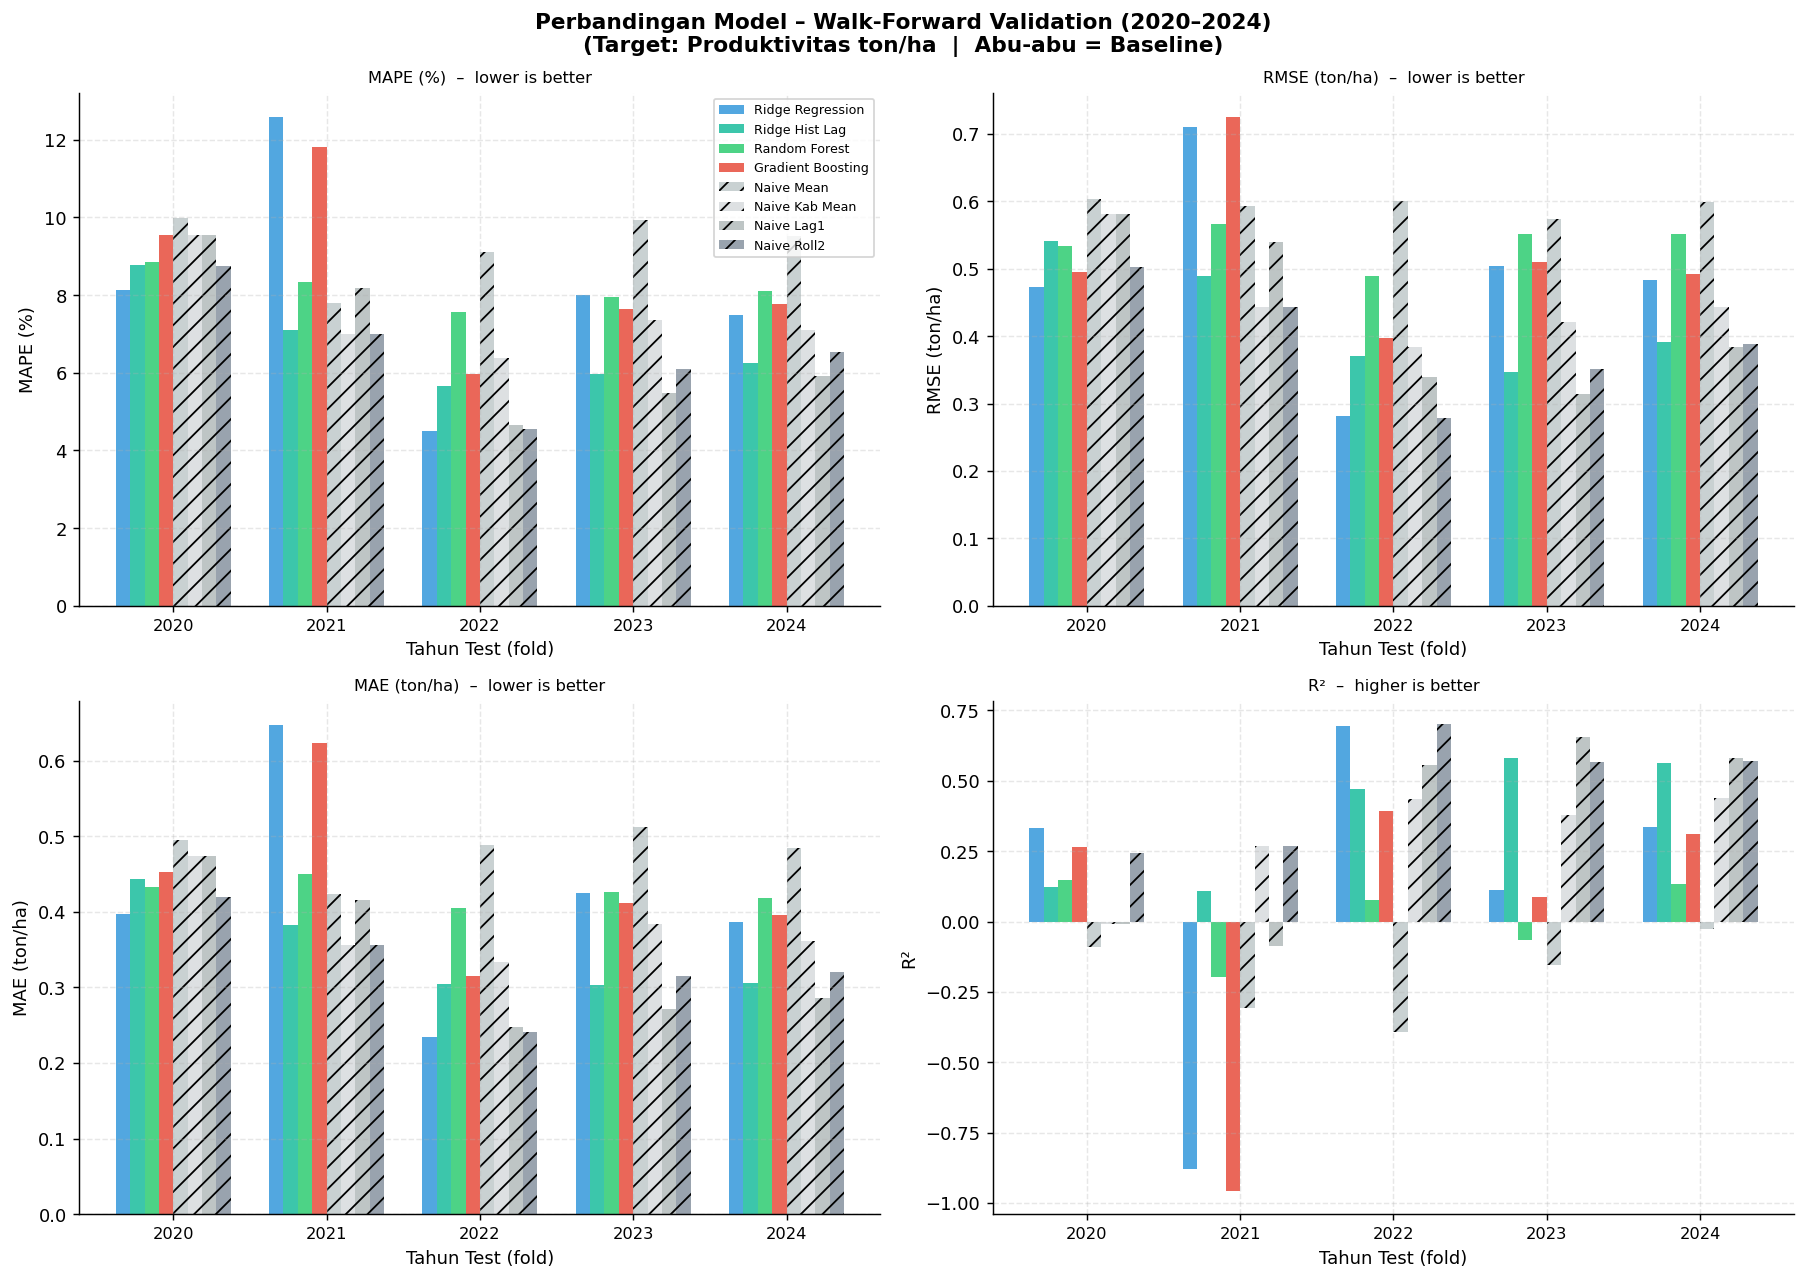

In [21]:
# Visualisasi perbandingan per fold
model_colors = {
    'Ridge Regression'  : '#3498db',
    'Ridge Hist Lag'    : '#1abc9c',
    'Random Forest'     : '#2ecc71',
    'Gradient Boosting' : '#e74c3c',
    'Naive Mean'        : '#95a5a6',
    'Naive Kab Mean'    : '#bdc3c7',
    'Naive Lag1'        : '#7f8c8d',
    'Naive Roll2'       : '#34495e',
}
metrik_plot = [
    ('mape', 'MAPE (%)',      'lower is better'),
    ('rmse', 'RMSE (ton/ha)', 'lower is better'),
    ('mae',  'MAE (ton/ha)',  'lower is better'),
    ('r2',   'R²',            'higher is better'),
]

n_fold = len(TAHUN_TEST_WFV)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perbandingan Model – Walk-Forward Validation (2020–2024)\n'
             '(Target: Produktivitas ton/ha  |  Abu-abu = Baseline)',
             fontsize=12, fontweight='bold')

for ax, (metrik, ylabel, note) in zip(axes.flat, metrik_plot):
    x_pos = np.arange(n_fold)
    n_mdl = len(SEMUA_MODEL)
    width = 0.75 / n_mdl

    for i, name in enumerate(SEMUA_MODEL):
        vals    = WFV_HASIL[name][metrik]
        is_base = name.startswith('Naive')
        alpha   = 0.5 if is_base else 0.85
        hatch   = '//' if is_base else ''
        ax.bar(x_pos + i * width, vals, width=width,
               color=model_colors.get(name, '#7f8c8d'), alpha=alpha,
               label=name, hatch=hatch)

    ax.set_xticks(x_pos + width * (n_mdl - 1) / 2)
    ax.set_xticklabels([str(t) for t in TAHUN_TEST_WFV], fontsize=9)
    ax.set_xlabel('Tahun Test (fold)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel}  –  {note}', fontsize=9)

axes.flat[0].legend(fontsize=7, loc='upper right')
plt.tight_layout()
save_figure('perbandingan_model_wfv.png')
plt.show()


## 4.3b Ablation Study – Kontribusi Kelompok Fitur

### Apa itu Ablation Study?

Ablation study adalah eksperimen sistematis yang menguji performa model ketika kelompok
fitur tertentu dimasukkan atau dikeluarkan. Tujuannya adalah memahami **fitur mana
yang benar-benar berkontribusi** pada prediksi, dan mana yang justru memperburuk performa.

### Mengapa Ablation Study Penting di Sini?

Pada dataset kecil seperti ini (90 sampel), ada risiko bahwa penambahan fitur justru
meningkatkan kompleksitas tanpa memberikan nilai prediktif nyata (*overfitting*).
Ablation study membantu mengidentifikasi kombinasi fitur yang paling efisien.

**Kelompok fitur yang diuji:**
- Histori target produktivitas saja
- Histori + efek kabupaten
- Histori + cuaca musiman
- Semua kombinasi di atas
- Cuaca saja (tanpa histori)

> Model yang digunakan: **Ridge Regression** (konsisten sebagai estimator standar untuk ablation).


In [22]:
FEATURE_SETS = {
    'Histori target ringkas': FITUR_HIST,
    'Histori + Kabupaten'  : FITUR_HIST_KAB,
    'Histori + Cuaca'      : FITUR_HIST_CUACA,
    'Histori + Cuaca + Kab': FITUR_HIST_FULL,
    'Cuaca saja'           : KOLOM_CUACA,
    'Cuaca + Luas Panen'   : KOLOM_CUACA + ['luas_panen_ha'],
    'Cuaca + Kabupaten'    : KOLOM_CUACA + KOLOM_KAB_OHE,
    'Full: Cuaca+Luas+Kab' : FITUR_MODEL,
}


def evaluate_wfv_estimator(estimator, feature_cols):
    rows = []
    for tahun_test in TAHUN_TEST_WFV:
        train_mask = df_fitur['tahun'] < tahun_test
        test_mask  = df_fitur['tahun'] == tahun_test
        X_tr = df_model.loc[train_mask, feature_cols].values.astype(float)
        y_tr = df_model.loc[train_mask, 'produktivitas_ton_per_ha'].values
        X_te = df_model.loc[test_mask, feature_cols].values.astype(float)
        y_te = df_model.loc[test_mask, 'produktivitas_ton_per_ha'].values

        m = copy.deepcopy(estimator)
        m.fit(X_tr, y_tr)
        y_pr = np.clip(m.predict(X_te), 0, None)
        rows.append({
            'tahun_test': tahun_test,
            'RMSE': np.sqrt(mean_squared_error(y_te, y_pr)),
            'MAE' : mean_absolute_error(y_te, y_pr),
            'R2'  : r2_score(y_te, y_pr),
            'MAPE': hitung_mape(y_te, y_pr),
        })
    return pd.DataFrame(rows)

ablation_rows = []
for feature_set_name, cols in FEATURE_SETS.items():
    hasil = evaluate_wfv_estimator(MODELDEFS['Ridge Regression'], cols)
    ablation_rows.append({
        'Feature Set': feature_set_name,
        'Jumlah Fitur': len(cols),
        'MAPE mean (%)': hasil['MAPE'].mean(),
        'MAPE std (%)' : hasil['MAPE'].std(),
        'RMSE mean'    : hasil['RMSE'].mean(),
        'R2 mean'      : hasil['R2'].mean(),
    })

df_ablation = (pd.DataFrame(ablation_rows)
               .sort_values('MAPE mean (%)')
               .reset_index(drop=True))
from IPython.display import display

# Tandai baris terbaik
best_idx = df_ablation['MAPE mean (%)'].idxmin()

def highlight_ablation(row):
    if row.name == best_idx:
        return ['background-color: #d4edda; font-weight: bold'] * len(row)
    return [''] * len(row)

display(
    df_ablation.style
    .apply(highlight_ablation, axis=1)
    .format({
        'MAPE mean (%)': '{:.2f}%',
        'MAPE std (%)': '{:.2f}%',
        'RMSE mean': '{:.4f}',
        'R2 mean': '{:.4f}',
        'Jumlah Fitur': '{:.0f}',
    })
    .set_caption("Ablation Study – Ridge Regression | Walk-Forward Validation 2020–2024 | Diurutkan MAPE terkecil")
    .bar(subset=['MAPE mean (%)'], color='#f4c2c2', vmin=0)
)

# Interpretasi otomatis
print()
print("=== Interpretasi Ablation Study ===")
best_set   = df_ablation.loc[best_idx, 'Feature Set']
best_mape  = df_ablation.loc[best_idx, 'MAPE mean (%)']
worst_set  = df_ablation.loc[df_ablation['MAPE mean (%)'].idxmax(), 'Feature Set']
worst_mape = df_ablation['MAPE mean (%)'].max()

print(f"Kombinasi fitur terbaik : '{best_set}' (MAPE = {best_mape:.2f}%)")
print(f"Kombinasi fitur terlemah: '{worst_set}' (MAPE = {worst_mape:.2f}%)")
print()

hist_mape  = df_ablation.loc[df_ablation['Feature Set'] == 'Histori target ringkas', 'MAPE mean (%)'].values
cuaca_mape = df_ablation.loc[df_ablation['Feature Set'] == 'Cuaca saja', 'MAPE mean (%)'].values
if len(hist_mape) and len(cuaca_mape):
    print(f"Histori produktivitas saja    : MAPE = {hist_mape[0]:.2f}%")
    print(f"Cuaca saja                    : MAPE = {cuaca_mape[0]:.2f}%")
    if hist_mape[0] < cuaca_mape[0]:
        selisih = cuaca_mape[0] - hist_mape[0]
        print(f"  -> Riwayat produktivitas ({selisih:.2f} poin lebih baik) lebih informatif dari cuaca saja.")
        print("     Ini mengindikasikan persistensi produktivitas antar tahun di level kabupaten.")
    else:
        print("  -> Cuaca saja sedikit lebih baik dari histori saja pada konfigurasi ini.")

full_mape = df_ablation.loc[df_ablation['Feature Set'] == 'Full: Cuaca+Luas+Kab', 'MAPE mean (%)'].values
if len(full_mape) and full_mape[0] > best_mape + 0.5:
    print(f"\nPenambahan seluruh fitur ('Full') menghasilkan MAPE {full_mape[0]:.2f}%,")
    print(f"lebih tinggi dari konfigurasi terbaik ({best_mape:.2f}%). Ini adalah tanda overfitting")
    print("yang khas pada dataset kecil — lebih banyak fitur tidak selalu berarti lebih akurat.")


,Feature Set,Jumlah Fitur,MAPE mean (%),MAPE std (%),RMSE mean,R2 mean
0,Histori target ringkas,2,6.74%,1.15%,0.4338,0.3517
1,Histori + Kabupaten,16,7.16%,0.72%,0.4445,0.3297
2,Full: Cuaca+Luas+Kab,33,8.14%,2.89%,0.4904,0.1181
3,Cuaca + Kabupaten,32,8.37%,2.98%,0.4970,0.0962
4,Histori + Cuaca + Kab,34,8.59%,2.87%,0.5129,0.0447
5,Cuaca + Luas Panen,19,11.06%,4.58%,0.6550,-0.6143
6,Histori + Cuaca,20,11.39%,6.15%,0.6504,-0.6784
7,Cuaca saja,18,12.56%,5.78%,0.7289,-0.9749



=== Interpretasi Ablation Study ===
Kombinasi fitur terbaik : 'Histori target ringkas' (MAPE = 6.74%)
Kombinasi fitur terlemah: 'Cuaca saja' (MAPE = 12.56%)

Histori produktivitas saja    : MAPE = 6.74%
Cuaca saja                    : MAPE = 12.56%
  -> Riwayat produktivitas (5.82 poin lebih baik) lebih informatif dari cuaca saja.
     Ini mengindikasikan persistensi produktivitas antar tahun di level kabupaten.

Penambahan seluruh fitur ('Full') menghasilkan MAPE 8.14%,
lebih tinggi dari konfigurasi terbaik (6.74%). Ini adalah tanda overfitting
yang khas pada dataset kecil — lebih banyak fitur tidak selalu berarti lebih akurat.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 4.4 Evaluasi Final – Model Terbaik (Train 2019–2023, Test 2024)

Evaluasi akhir menggunakan **split kronologis paling realistis**: model dilatih pada
seluruh data historis (2019–2023) dan diuji pada data tahun terbaru (2024).

Split ini mensimulasikan skenario penggunaan nyata: sebuah model dilatih dari data
historis yang tersedia, kemudian digunakan untuk memprediksi tahun mendatang.

### Catatan Penting: R² Produktivitas vs R² Produksi

Dua metrik R² yang dilaporkan di bawah ini terlihat kontradiktif namun bukan inkonsistensi:

- **R² produktivitas** (ton/ha): ukuran kemampuan prediksi model yang sesungguhnya
- **R² produksi** (ton): sering sangat tinggi karena **didominasi variansi luas panen** antar kabupaten,
  bukan kemampuan prediksi model

> Rumus: `Produksi = Produktivitas x Luas Panen`. Variansi luas panen antar kabupaten
> sangat besar (dari ratusan hingga ratusan ribu hektar), sehingga R² produksi
> mencerminkan pengetahuan luas panen — bukan prediksi model.
> **Gunakan R² produktivitas sebagai ukuran utama.**


In [23]:
mask_train = df_fitur['tahun'] <= 2023
mask_test  = df_fitur['tahun'] == 2024

fitur_final = MODEL_FEATURES[MODEL_TERBAIK]
X_train  = df_model.loc[mask_train, fitur_final].values.astype(float)
y_train  = df_model.loc[mask_train, 'produktivitas_ton_per_ha'].values
X_test   = df_model.loc[mask_test, fitur_final].values.astype(float)
y_test   = df_model.loc[mask_test, 'produktivitas_ton_per_ha'].values
meta_test = df_fitur[mask_test].copy().reset_index(drop=True)

# Train model ML terbaik berdasarkan WFV
model_final = copy.deepcopy(MODELDEFS[MODEL_TERBAIK])
model_final.fit(X_train, y_train)
y_pred_prodvt = np.clip(model_final.predict(X_test), 0, None)

# Train seluruh baseline final dan pilih baseline terbaik di test 2024 untuk analisis pembanding
meta_train = df_fitur[mask_train]
baseline_final_results = []
baseline_final_preds = {}


def metrik_set(y_true, y_pred, label):
    return {
        'label': label,
        'RMSE' : np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE'  : mean_absolute_error(y_true, y_pred),
        'R2'   : r2_score(y_true, y_pred),
        'MAPE' : hitung_mape(y_true, y_pred),
    }

for name, baseline_def in BASELINEDEFS.items():
    b = copy.deepcopy(baseline_def)
    b.fit(meta_train, y_train)
    y_pred_base = b.predict(meta_test)
    baseline_final_preds[name] = y_pred_base
    baseline_final_results.append(metrik_set(y_test, y_pred_base, name))

df_final_baseline = pd.DataFrame(baseline_final_results).sort_values('MAPE').reset_index(drop=True)
BASELINE_FINAL_TERBAIK = df_final_baseline.loc[0, 'label']
y_pred_baseline_best = baseline_final_preds[BASELINE_FINAL_TERBAIK]

# Prediksi produksi (turunan) dan error analysis
meta_test['prodvt_aktual']             = y_test
meta_test['prodvt_prediksi']           = y_pred_prodvt
meta_test['prodvt_prediksi_baseline']  = y_pred_baseline_best
meta_test['residual_prodvt']           = y_pred_prodvt - y_test
meta_test['abs_error_prodvt']          = np.abs(meta_test['residual_prodvt'])
meta_test['produksi_prediksi_ton']     = y_pred_prodvt * meta_test['luas_panen_ha']
meta_test['produksi_error_ton']        = meta_test['produksi_prediksi_ton'] - meta_test['produksi_ton']
meta_test['produksi_error_pct']        = meta_test['produksi_error_ton'] / meta_test['produksi_ton'].abs().clip(lower=1e-8) * 100

# Alias backward-compatible untuk cell visualisasi lama
y_pred_nk = y_pred_baseline_best

# Metrik produktivitas
m_prodvt_ml = metrik_set(y_test, y_pred_prodvt, MODEL_TERBAIK)
m_prodvt_nk = metrik_set(y_test, y_pred_baseline_best, BASELINE_FINAL_TERBAIK)

# Metrik produksi (turunan)
y_prod_akt  = meta_test['produksi_ton'].values
y_prod_pred = meta_test['produksi_prediksi_ton'].values
rmse_prod = np.sqrt(mean_squared_error(y_prod_akt, y_prod_pred))
r2_prod   = r2_score(y_prod_akt, y_prod_pred)
mape_prod = hitung_mape(y_prod_akt, y_prod_pred)

sep = '=' * 65
from IPython.display import display

print(f"Evaluasi Final: {MODEL_TERBAIK}")
print(f"Training: 2019–2023 ({X_train.shape[0]} sampel)  |  Test: 2024 (15 sampel)")
print(f"Jumlah fitur model final: {len(fitur_final)}")
print()

# Tabel metrik produktivitas
all_results = [m_prodvt_ml] + baseline_final_results
df_eval = pd.DataFrame(all_results).set_index('label')
df_eval = df_eval.rename(columns={'RMSE': 'RMSE (t/ha)', 'MAE': 'MAE (t/ha)', 'R2': 'R²', 'MAPE': 'MAPE (%)'})
df_eval = df_eval.sort_values('MAPE (%)')

def highlight_eval(row):
    if row.name == MODEL_TERBAIK:
        return ['background-color: #d4edda; font-weight: bold'] * len(row)
    elif row.name == BASELINE_FINAL_TERBAIK:
        return ['background-color: #fff3cd'] * len(row)
    return ['color: #6c757d'] * len(row)

display(
    df_eval.style
    .apply(highlight_eval, axis=1)
    .format({'RMSE (t/ha)': '{:.4f}', 'MAE (t/ha)': '{:.4f}', 'R²': '{:.4f}', 'MAPE (%)': '{:.2f}%'})
    .set_caption("Metrik Produktivitas (ton/ha) – Evaluasi Final Test 2024 | Diurutkan MAPE terkecil")
)

print()
print(f"Catatan R² produksi (turunan): {r2_prod:.4f}")
print(f"  Nilai R² ini tampak tinggi karena didominasi variansi luas panen antar kabupaten.")
print(f"  MAPE produksi: {mape_prod:.2f}% | RMSE produksi: {rmse_prod/1e3:.1f} ribu ton")
print()

delta_mape_final = m_prodvt_nk['MAPE'] - m_prodvt_ml['MAPE']
print("--- Interpretasi Hasil ---")
# Interpretasi MAPE ML
mape_ml = m_prodvt_ml['MAPE']
if mape_ml < 5:
    interpret_mape = f"MAPE {mape_ml:.2f}% termasuk sangat baik (di bawah 5%)."
elif mape_ml < 10:
    interpret_mape = f"MAPE {mape_ml:.2f}% termasuk baik (di bawah 10%)."
elif mape_ml < 20:
    interpret_mape = f"MAPE {mape_ml:.2f}% termasuk moderat."
else:
    interpret_mape = f"MAPE {mape_ml:.2f}% masih cukup tinggi; ada ruang perbaikan."
print(f"Model {MODEL_TERBAIK}: {interpret_mape}")
print(f"  Rata-rata prediksi meleset sekitar {m_prodvt_ml['MAE']:.3f} ton/ha dari nilai aktual.")

r2_ml = m_prodvt_ml['R2']
if r2_ml > 0:
    print(f"  R² = {r2_ml:.4f}: model mampu menjelaskan sekitar {r2_ml*100:.1f}% variasi produktivitas.")
else:
    print(f"  R² = {r2_ml:.4f}: model belum menjelaskan variasi produktivitas lebih baik dari rata-rata.")

print()
if delta_mape_final > 0:
    print(f"Hasil dibanding baseline: Model ML mengungguli {BASELINE_FINAL_TERBAIK} sebesar {delta_mape_final:.2f} poin MAPE.")
else:
    print(f"Hasil dibanding baseline: Model ML belum mengungguli {BASELINE_FINAL_TERBAIK} pada test 2024 (selisih {abs(delta_mape_final):.2f} poin).")
    print("  Ini merupakan temuan yang valid dan penting untuk dilaporkan secara transparan.")


Evaluasi Final: Ridge Hist Lag
Training: 2019–2023 (75 sampel)  |  Test: 2024 (15 sampel)
Jumlah fitur model final: 2



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,RMSE (t/ha),MAE (t/ha),R²,MAPE (%)
label,,,,
Naive Lag1,0.3835,0.2861,0.5802,5.92%
Ridge Hist Lag,0.3906,0.3054,0.5644,6.26%
Naive Roll2,0.3876,0.3200,0.5710,6.54%
Naive Kab Mean,0.4437,0.3613,0.4379,7.10%
Naive Mean,0.5996,0.4850,-0.0265,9.51%



Catatan R² produksi (turunan): 0.9945
  Nilai R² ini tampak tinggi karena didominasi variansi luas panen antar kabupaten.
  MAPE produksi: 6.26% | RMSE produksi: 13.2 ribu ton

--- Interpretasi Hasil ---
Model Ridge Hist Lag: MAPE 6.26% termasuk baik (di bawah 10%).
  Rata-rata prediksi meleset sekitar 0.305 ton/ha dari nilai aktual.
  R² = 0.5644: model mampu menjelaskan sekitar 56.4% variasi produktivitas.

Hasil dibanding baseline: Model ML belum mengungguli Naive Lag1 pada test 2024 (selisih 0.34 poin).
  Ini merupakan temuan yang valid dan penting untuk dilaporkan secara transparan.


---

# 5. Visualisasi dan Analisis Error

## 5.1 Scatter Plot: Prediksi vs Aktual (Test 2024)

Scatter plot membandingkan nilai prediksi model terhadap nilai aktual untuk setiap
kabupaten di tahun test 2024. Titik yang mendekati garis diagonal merah (garis ideal
prediksi sempurna) menunjukkan prediksi yang akurat.

- **Panel kiri:** produktivitas (ton/ha) — ukuran kemampuan model
- **Panel kanan:** produksi turunan (ribu ton) — hasil kali produktivitas prediksi dengan luas panen aktual


[SAVED] results/Images/scatter_prediksi_aktual.png


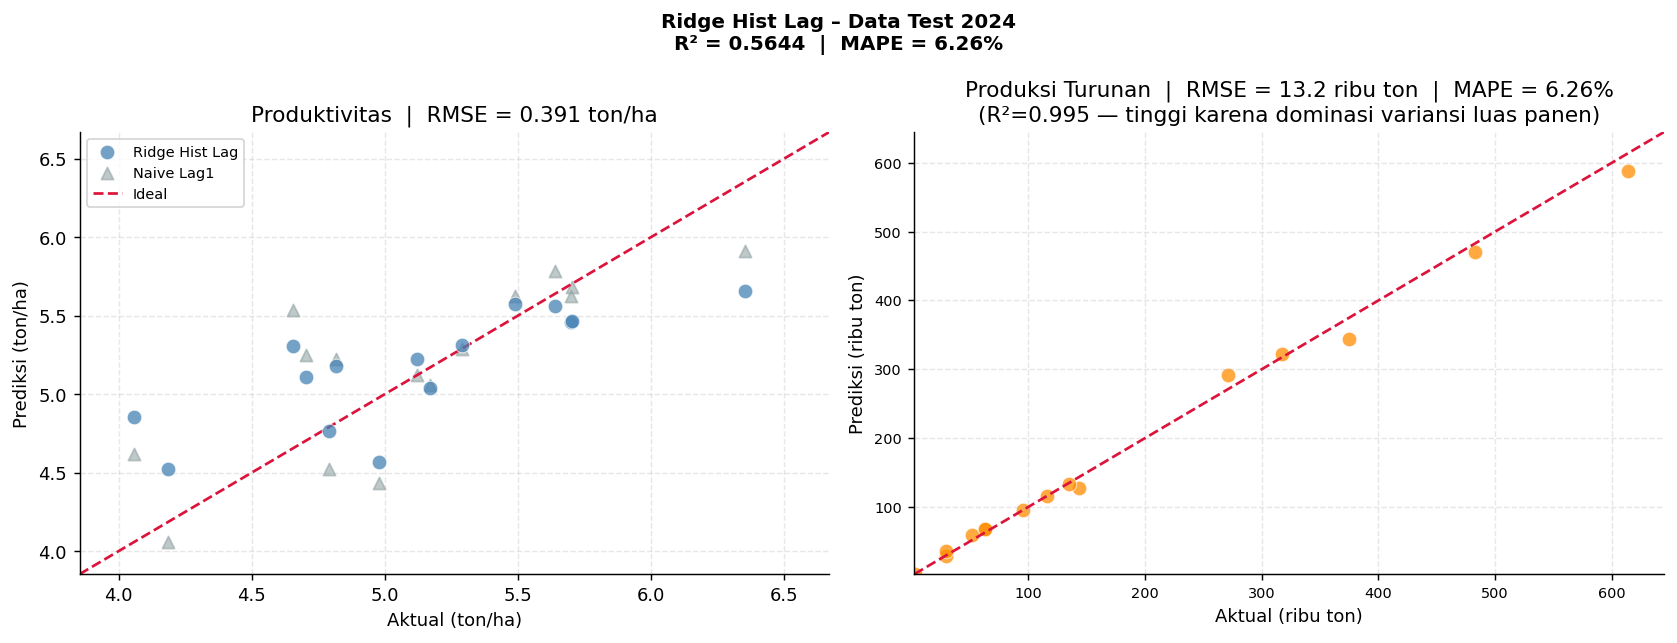

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'{MODEL_TERBAIK} – Data Test 2024\n'
             f'R² = {m_prodvt_ml["R2"]:.4f}  |  MAPE = {m_prodvt_ml["MAPE"]:.2f}%',
             fontsize=11, fontweight='bold')

# Scatter produktivitas
ax = axes[0]
ax.scatter(y_test, y_pred_prodvt, color='steelblue', alpha=0.75,
           s=65, edgecolors='white', linewidth=0.5, zorder=3, label=MODEL_TERBAIK)
ax.scatter(y_test, y_pred_nk, color='#95a5a6', alpha=0.6,
           s=45, marker='^', zorder=2, label=BASELINE_FINAL_TERBAIK)
lim = [min(y_test.min(), y_pred_prodvt.min()) * 0.95,
       max(y_test.max(), y_pred_prodvt.max()) * 1.05]
ax.plot(lim, lim, '--', color='crimson', linewidth=1.5, label='Ideal')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Aktual (ton/ha)')
ax.set_ylabel('Prediksi (ton/ha)')
ax.set_title(f'Produktivitas  |  RMSE = {m_prodvt_ml["RMSE"]:.3f} ton/ha')
ax.legend(fontsize=8)

# Scatter produksi turunan
ax = axes[1]
ax.scatter(y_prod_akt / 1e3, y_prod_pred / 1e3,
           color='darkorange', alpha=0.75, s=65, edgecolors='white', linewidth=0.5)
lim2 = [min(y_prod_akt.min(), y_prod_pred.min()) / 1e3 * 0.9,
        max(y_prod_akt.max(), y_prod_pred.max()) / 1e3 * 1.05]
ax.plot(lim2, lim2, '--', color='crimson', linewidth=1.5)
ax.set_xlim(lim2); ax.set_ylim(lim2)
ax.set_xlabel('Aktual (ribu ton)')
ax.set_ylabel('Prediksi (ribu ton)')
ax.set_title(f'Produksi Turunan  |  RMSE = {rmse_prod/1e3:.1f} ribu ton  |  MAPE = {mape_prod:.2f}%\n'
             f'(R²={r2_prod:.3f} — tinggi karena dominasi variansi luas panen)')
ax.tick_params(labelsize=8)

plt.tight_layout()
save_figure('scatter_prediksi_aktual.png')
plt.show()


## 5.1b Analisis Residual dan Arah Bias Prediksi

Analisis residual memberikan informasi lebih mendalam tentang karakteristik error model:
apakah model cenderung memprediksi terlalu tinggi (*over-prediction*) atau terlalu rendah
(*under-prediction*) untuk kabupaten tertentu.

- **Batang biru:** model memprediksi lebih rendah dari aktual (*under-prediction*)
- **Batang merah:** model memprediksi lebih tinggi dari aktual (*over-prediction*)
- **Garis oranye putus-putus:** batas ±15% sebagai acuan akurasi

Informasi ini berguna untuk mengidentifikasi apakah model memiliki bias sistematis
terhadap wilayah tertentu.


[SAVED] results/Images/residual_analysis_2024.png


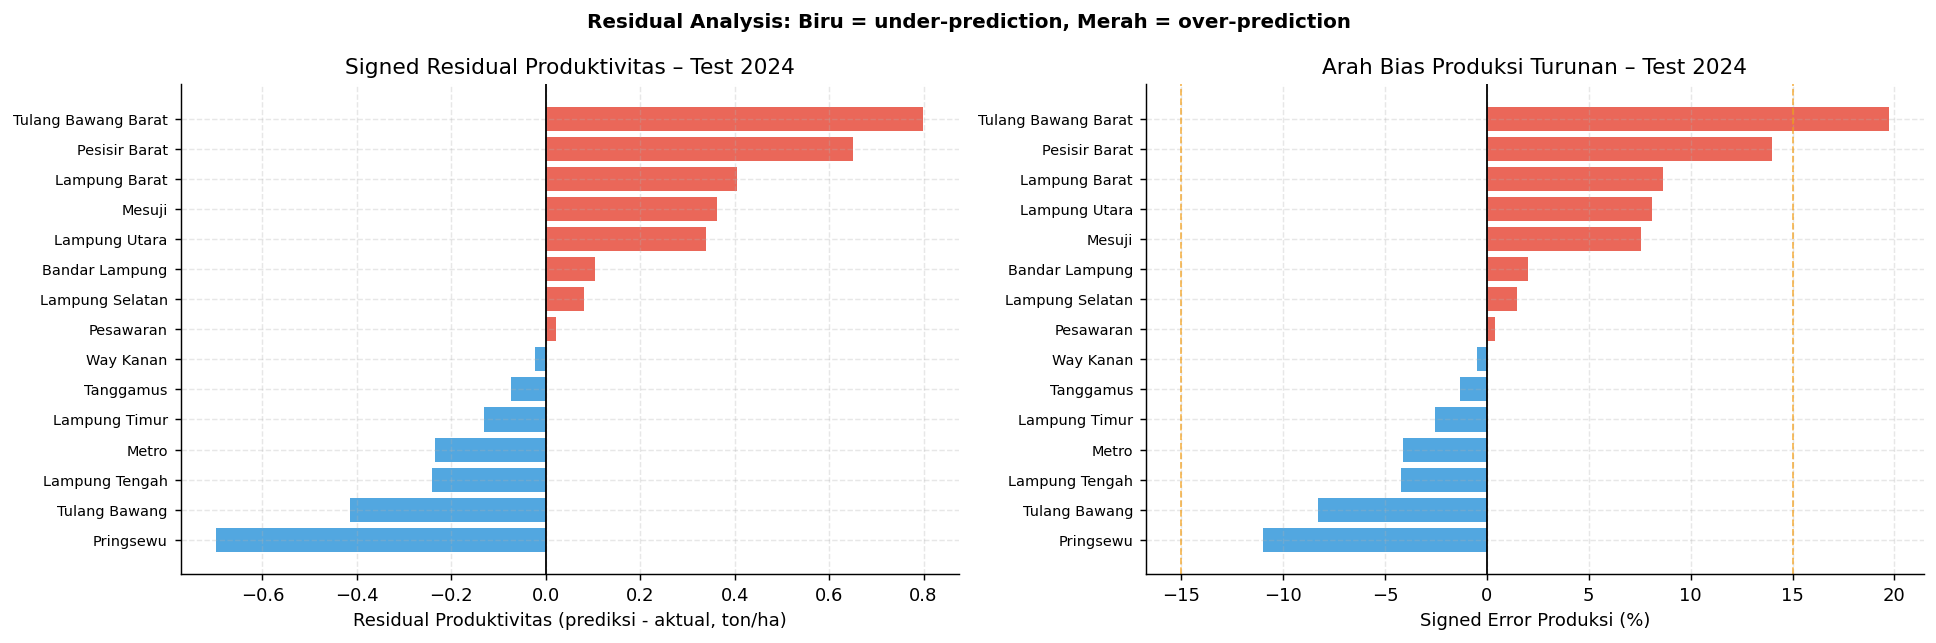


=== Interpretasi Residual ===
Over-prediction  (terlalu tinggi): 8 kabupaten
Under-prediction (terlalu rendah): 7 kabupaten
Over-prediction terbesar : Tulang Bawang Barat (+0.800 t/ha)
Under-prediction terbesar: Pringsewu (-0.699 t/ha)
Bias rata-rata (mean residual): +0.0632 t/ha
  -> Model cenderung sedikit over-predicting secara rata-rata.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
residual_plot = meta_test.sort_values('residual_prodvt')
colors_res = ['#e74c3c' if v > 0 else '#3498db' for v in residual_plot['residual_prodvt']]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.barh(residual_plot['kabupaten'], residual_plot['residual_prodvt'], color=colors_res, alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Residual Produktivitas (prediksi - aktual, ton/ha)')
ax.set_title('Signed Residual Produktivitas – Test 2024')
ax.tick_params(axis='y', labelsize=8)

ax = axes[1]
err_pct_plot = meta_test.sort_values('produksi_error_pct')
colors_pct = ['#e74c3c' if v > 0 else '#3498db' for v in err_pct_plot['produksi_error_pct']]
ax.barh(err_pct_plot['kabupaten'], err_pct_plot['produksi_error_pct'], color=colors_pct, alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(15, color='#f39c12', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(-15, color='#f39c12', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Signed Error Produksi (%)')
ax.set_title('Arah Bias Produksi Turunan – Test 2024')
ax.tick_params(axis='y', labelsize=8)

fig.suptitle('Residual Analysis: Biru = under-prediction, Merah = over-prediction',
             fontsize=11, fontweight='bold')
plt.tight_layout()
save_figure('residual_analysis_2024.png')
plt.show()

# Interpretasi otomatis residual
print()
print("=== Interpretasi Residual ===")
over_pred  = (meta_test['residual_prodvt'] > 0).sum()
under_pred = (meta_test['residual_prodvt'] < 0).sum()
print(f"Over-prediction  (terlalu tinggi): {over_pred} kabupaten")
print(f"Under-prediction (terlalu rendah): {under_pred} kabupaten")
max_over  = meta_test.loc[meta_test['residual_prodvt'].idxmax(), ['kabupaten', 'residual_prodvt']]
max_under = meta_test.loc[meta_test['residual_prodvt'].idxmin(), ['kabupaten', 'residual_prodvt']]
print(f"Over-prediction terbesar : {max_over['kabupaten']} ({max_over['residual_prodvt']:+.3f} t/ha)")
print(f"Under-prediction terbesar: {max_under['kabupaten']} ({max_under['residual_prodvt']:+.3f} t/ha)")
bias_global = meta_test['residual_prodvt'].mean()
print(f"Bias rata-rata (mean residual): {bias_global:+.4f} t/ha")
if abs(bias_global) < 0.05:
    print("  -> Error terpusat di sekitar nol; tidak ada bias sistematis yang signifikan.")
elif bias_global > 0:
    print("  -> Model cenderung sedikit over-predicting secara rata-rata.")
else:
    print("  -> Model cenderung sedikit under-predicting secara rata-rata.")


## 5.2 Perbandingan Produksi Aktual vs Prediksi per Kabupaten (2024)

Grafik batang berdampingan membandingkan produksi aktual (biru) dengan produksi
prediksi (oranye) untuk setiap kabupaten di tahun 2024.

Angka persentase di atas setiap pasang batang adalah MAPE per kabupaten:
- **Hijau** (< 15%): prediksi akurat
- **Oranye** (15–30%): prediksi cukup baik
- **Merah** (> 30%): prediksi masih perlu ditingkatkan


[SAVED] results/Images/bar_per_kabupaten_2024.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


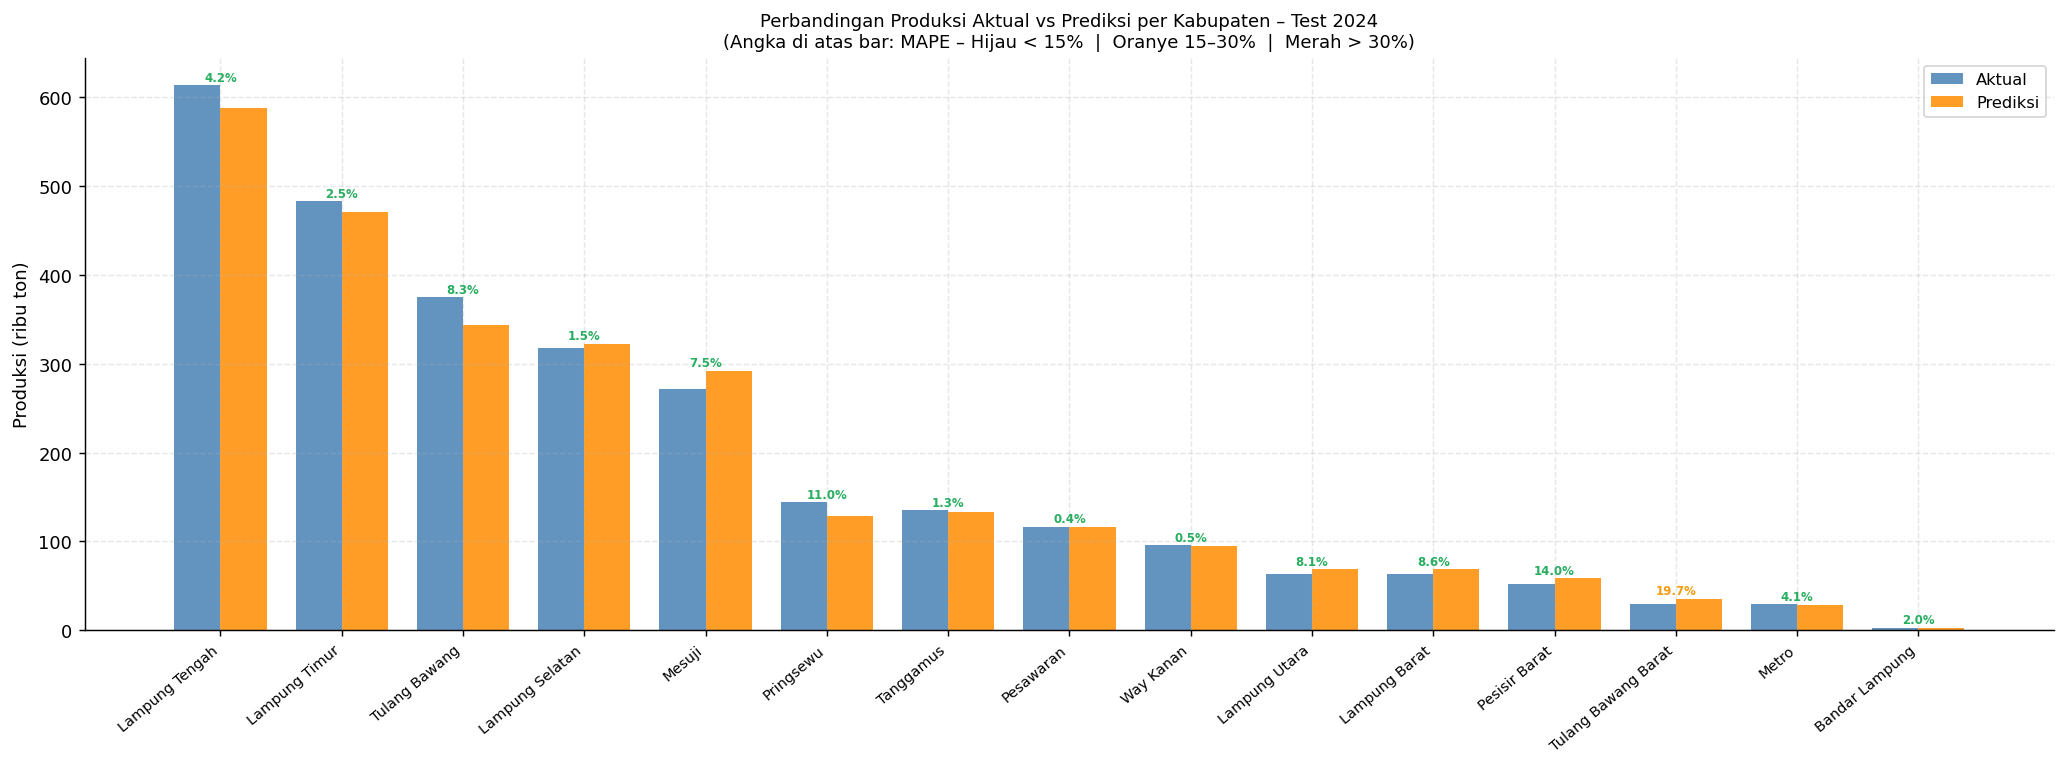

In [26]:
kab_sorted = meta_test.sort_values('produksi_ton', ascending=False)['kabupaten'].values
x_pos      = np.arange(len(kab_sorted))
width      = 0.38

akt_vals  = [meta_test[meta_test['kabupaten'] == k]['produksi_ton'].values[0] / 1e3
             for k in kab_sorted]
pred_vals = [meta_test[meta_test['kabupaten'] == k]['produksi_prediksi_ton'].values[0] / 1e3
             for k in kab_sorted]
mape_vals = [abs(a - p) / max(a, 1e-8) * 100 for a, p in zip(akt_vals, pred_vals)]

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x_pos - width / 2, akt_vals,  width=width, color='steelblue',
       alpha=0.85, label='Aktual')
ax.bar(x_pos + width / 2, pred_vals, width=width, color='darkorange',
       alpha=0.85, label='Prediksi')

for i, (a, p, mp) in enumerate(zip(akt_vals, pred_vals, mape_vals)):
    clr = '#27ae60' if mp < 15 else ('#f39c12' if mp < 30 else '#e74c3c')
    ax.text(x_pos[i], max(a, p) + 1.5, f'{mp:.1f}%',
            ha='center', va='bottom', fontsize=6.5, color=clr, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(kab_sorted, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Produksi (ribu ton)')
ax.set_title(f'Perbandingan Produksi Aktual vs Prediksi per Kabupaten – Test 2024\n'
             f'(Angka di atas bar: MAPE – Hijau < 15%  |  Oranye 15–30%  |  Merah > 30%)',
             fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
save_figure('bar_per_kabupaten_2024.png')
plt.show()


## 5.3 Feature Importance

Feature importance mengukur seberapa besar kontribusi masing-masing fitur terhadap
prediksi model. Untuk Ridge Regression, nilai importance diambil dari koefisien
regresi (nilai absolut).

- **Panel kiri:** 20 fitur individu dengan importance tertinggi
- **Panel kanan:** importance agregasi per kelompok fitur

Memahami feature importance membantu mengidentifikasi variabel mana yang paling
berpengaruh terhadap prediksi produktivitas padi.


[SAVED] results/Images/feature_importance.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


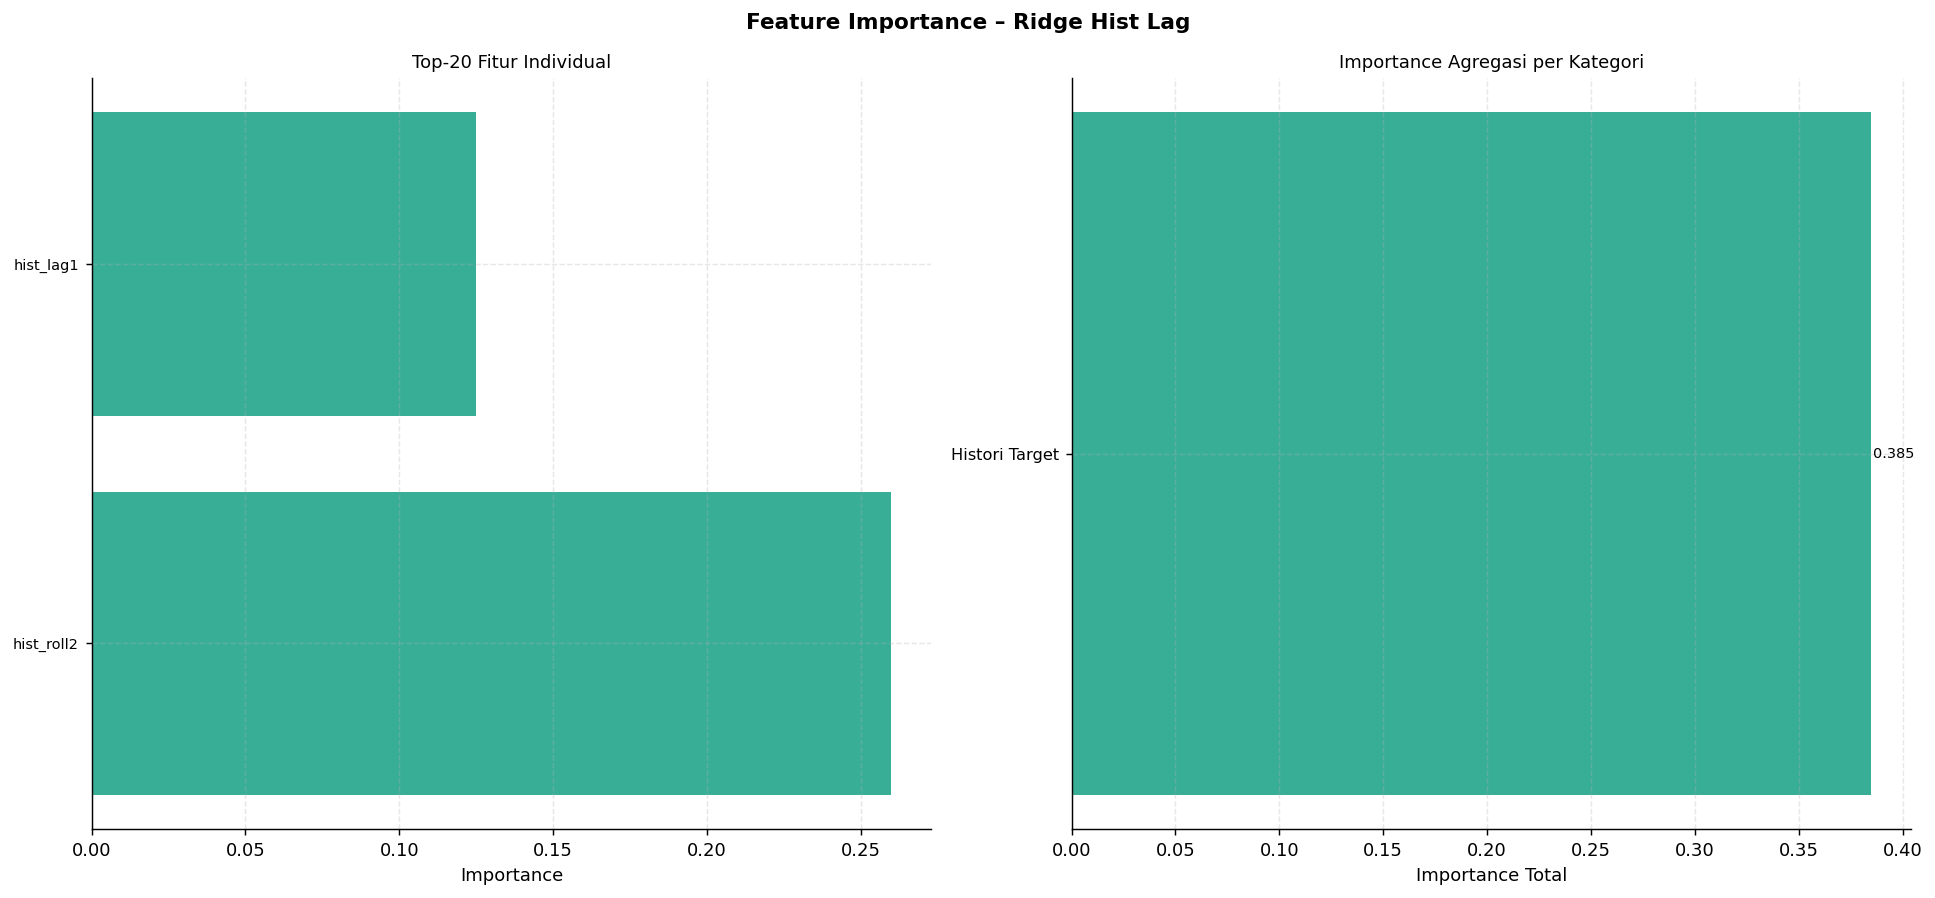

In [27]:
if hasattr(model_final, 'feature_importances_'):
    importances = model_final.feature_importances_
elif hasattr(model_final, 'named_steps'):
    inner       = model_final.named_steps.get('model')
    importances = np.abs(inner.coef_) if hasattr(inner, 'coef_') else None
else:
    importances = None

if importances is not None:
    fitur_importance = fitur_final if 'fitur_final' in globals() else FITUR_MODEL
    df_imp = pd.DataFrame({
        'fitur'     : fitur_importance,
        'importance': importances,
    }).sort_values('importance', ascending=False)

    df_imp['kategori'] = df_imp['fitur'].apply(
        lambda c: 'Kabupaten (OHE)' if c.startswith('kabupaten_') else
                  ('Histori Target' if c.startswith('prodvt_') else
                  ('Luas Panen'     if c == 'luas_panen_ha' else
                   ('Utama: '   + c.split('_utama')[0].replace('ALLSKY_SFC_SW_DWN', 'Radiasi')
                                                       .replace('PRECTOTCORR', 'CurahHujan')
                    if '_utama_'   in c else
                    ('Gadu: '   + c.split('_gadu')[0].replace('ALLSKY_SFC_SW_DWN', 'Radiasi')
                                                      .replace('PRECTOTCORR', 'CurahHujan')
                    if '_gadu_'    in c else
                    'Kemarau: ' + c.split('_kemarau')[0].replace('ALLSKY_SFC_SW_DWN', 'Radiasi')
                                                         .replace('PRECTOTCORR', 'CurahHujan')
                    ))))
    )
    df_agg_imp = df_imp.groupby('kategori')['importance'].sum().sort_values(ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    fig.suptitle(f'Feature Importance – {MODEL_TERBAIK}', fontsize=12, fontweight='bold')

    top20       = df_imp.head(20)
    colors_imp  = ['#e74c3c' if 'kabupaten' in c else
                   '#16a085' if c.startswith('prodvt_') else
                   '#27ae60' if '_utama_'   in c else
                   '#f39c12' if '_gadu_'    in c else
                   '#8e44ad' if '_kemarau_' in c else '#2980b9'
                   for c in top20['fitur']]
    axes[0].barh(range(len(top20)), top20['importance'].values,
                 color=colors_imp, alpha=0.85)
    axes[0].set_yticks(range(len(top20)))
    axes[0].set_yticklabels(
        [c.replace('ALLSKY_SFC_SW_DWN', 'Radiasi')
          .replace('PRECTOTCORR', 'CurahHujan')
          .replace('kabupaten_', 'kab:')
          .replace('luas_panen_ha', 'LuasPanen')
          .replace('prodvt_', 'hist_')
         for c in top20['fitur']],
        fontsize=8
    )
    axes[0].set_title('Top-20 Fitur Individual', fontsize=10)
    axes[0].set_xlabel('Importance')

    colors_cat = ['#95a5a6' if 'Kabupaten' in c else
                  '#16a085' if 'Histori'   in c else
                  '#27ae60' if 'Utama'     in c else
                  '#f39c12' if 'Gadu'      in c else
                  '#8e44ad' if 'Kemarau'   in c else '#2980b9'
                  for c in df_agg_imp.index]
    axes[1].barh(range(len(df_agg_imp)), df_agg_imp.values,
                 color=colors_cat, alpha=0.85)
    axes[1].set_yticks(range(len(df_agg_imp)))
    axes[1].set_yticklabels(df_agg_imp.index, fontsize=9)
    axes[1].set_title('Importance Agregasi per Kategori', fontsize=10)
    axes[1].set_xlabel('Importance Total')
    for i, v in enumerate(df_agg_imp.values):
        axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

    plt.tight_layout()
    save_figure('feature_importance.png')
    plt.show()
else:
    print("Model tidak menyediakan feature importances.")


## 5.4 Distribusi Akurasi per Kabupaten (Test 2024)

Grafik ini menampilkan MAPE prediksi produksi turunan untuk setiap kabupaten,
diurutkan dari yang paling akurat hingga paling tidak akurat.

Visualisasi ini penting untuk menilai apakah model bekerja secara **konsisten**
di semua wilayah, atau hanya akurat di beberapa kabupaten saja.


[SAVED] results/Images/mape_per_kabupaten.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


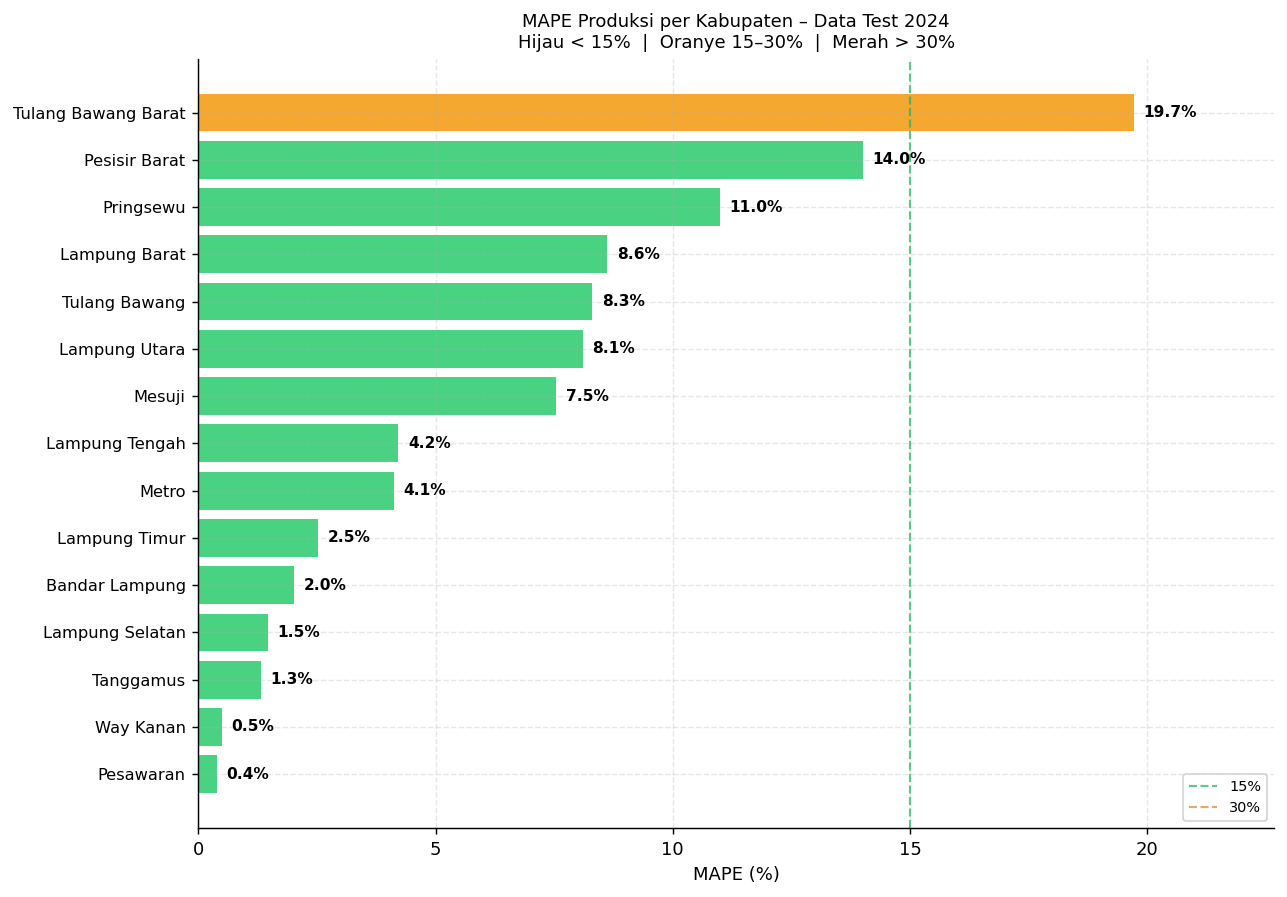


=== Interpretasi Distribusi Akurasi per Kabupaten ===
Akurat   (MAPE < 15%) : 14 kabupaten ['Pesawaran', 'Way Kanan', 'Tanggamus', 'Lampung Selatan', 'Bandar Lampung', 'Lampung Timur', 'Metro', 'Lampung Tengah', 'Mesuji', 'Lampung Utara', 'Tulang Bawang', 'Lampung Barat', 'Pringsewu', 'Pesisir Barat']
Moderat (15–30%)      : 1 kabupaten ['Tulang Bawang Barat']
Lemah   (> 30%)       : 0 kabupaten –

Standar deviasi MAPE antar kabupaten: 5.57%
  -> Performa model relatif konsisten antar kabupaten.


In [28]:
meta_test['mape_produksi'] = meta_test['produksi_error_pct'].abs()
mape_kab = meta_test[['kabupaten', 'mape_produksi']].sort_values('mape_produksi')

fig, ax = plt.subplots(figsize=(10, 7))
colors_mape = ['#2ecc71' if v < 15 else ('#f39c12' if v < 30 else '#e74c3c')
               for v in mape_kab['mape_produksi']]
bars = ax.barh(range(len(mape_kab)), mape_kab['mape_produksi'].values,
               color=colors_mape, alpha=0.88)
ax.set_yticks(range(len(mape_kab)))
ax.set_yticklabels(mape_kab['kabupaten'].values, fontsize=9)
for bar, val in zip(bars, mape_kab['mape_produksi'].values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left', fontsize=8.5, fontweight='bold')
ax.axvline(15, color='#27ae60', linestyle='--', linewidth=1.2, alpha=0.7, label='15%')
ax.axvline(30, color='#e67e22', linestyle='--', linewidth=1.2, alpha=0.7, label='30%')
ax.set_xlabel('MAPE (%)')
ax.set_title(f'MAPE Produksi per Kabupaten – Data Test 2024\n'
             f'Hijau < 15%  |  Oranye 15–30%  |  Merah > 30%', fontsize=10)
ax.set_xlim(0, mape_kab['mape_produksi'].max() * 1.15)
ax.legend(fontsize=8)
plt.tight_layout()
save_figure('mape_per_kabupaten.png')
plt.show()

# Interpretasi distribusi akurasi
print()
print("=== Interpretasi Distribusi Akurasi per Kabupaten ===")
akurat_list  = mape_kab[mape_kab['mape_produksi'] < 15]['kabupaten'].tolist()
moderat_list = mape_kab[(mape_kab['mape_produksi'] >= 15) & (mape_kab['mape_produksi'] < 30)]['kabupaten'].tolist()
lemah_list   = mape_kab[mape_kab['mape_produksi'] >= 30]['kabupaten'].tolist()
print(f"Akurat   (MAPE < 15%) : {len(akurat_list)} kabupaten {akurat_list if akurat_list else '–'}")
print(f"Moderat (15–30%)      : {len(moderat_list)} kabupaten {moderat_list if moderat_list else '–'}")
print(f"Lemah   (> 30%)       : {len(lemah_list)} kabupaten {lemah_list if lemah_list else '–'}")
print()
konsistensi = mape_kab['mape_produksi'].std()
print(f"Standar deviasi MAPE antar kabupaten: {konsistensi:.2f}%")
if konsistensi < 10:
    print("  -> Performa model relatif konsisten antar kabupaten.")
elif konsistensi < 20:
    print("  -> Ada variasi performa yang cukup signifikan antar kabupaten.")
else:
    print("  -> Performa sangat tidak merata antar kabupaten; model mungkin bias pada wilayah tertentu.")


---

# 6. Ringkasan dan Kesimpulan Penelitian

Bagian ini merangkum seluruh temuan penelitian dalam bentuk narasi yang mudah dipahami,
mencakup performa model, perbandingan dengan baseline, insight utama, dan keterbatasan
yang perlu dipertimbangkan dalam interpretasi hasil.


In [29]:
zona_hijau  = (mape_kab['mape_produksi'] < 15).sum()
zona_oranye = ((mape_kab['mape_produksi'] >= 15) & (mape_kab['mape_produksi'] < 30)).sum()
zona_merah  = (mape_kab['mape_produksi'] >= 30).sum()


def extract_model_params(model):
    """Ambil parameter utama, termasuk estimator di dalam sklearn Pipeline."""
    interesting = {'n_estimators', 'max_depth', 'learning_rate', 'subsample',
                   'min_samples_leaf', 'alpha', 'max_features'}
    if hasattr(model, 'named_steps') and 'model' in model.named_steps:
        inner = model.named_steps['model']
        params = inner.get_params()
    elif hasattr(model, 'get_params'):
        params = model.get_params()
    else:
        return {}
    return {k: v for k, v in params.items() if k in interesting}

# Parameter model ML terbaik
params_final = extract_model_params(model_final)

sep = '=' * 65
print(sep)
print("RINGKASAN AKHIR – PREDIKSI PRODUKTIVITAS & PRODUKSI PADI")
print("Provinsi Lampung | Machine Learning Berbasis Musim Tanam")
print(sep)
print(f"  Tanggal generate  : {datetime.date.today()}")
print(f"  Cakupan data      : 15 kabupaten, 2019–2024 (90 sampel)")
print()
print("  Desain Fitur:")
print(f"    Target           : produktivitas_ton_per_ha")
print(f"    Fitur cuaca      : {len(KOLOM_CUACA)} (3 musim × 6 parameter)")
print(f"    Fitur histori    : {len(HIST_FEATURES)} kandidat lag/rolling produktivitas")
print(f"    Fitur lain       : luas_panen_ha, kabupaten (OHE × {len(KOLOM_KAB_OHE)})")
print(f"    Total fitur default: {len(FITUR_MODEL)} | fitur final ML: {len(fitur_final)}")
print()
print("  Desain Musim Tanam:")
for nm, info in MUSIM.items():
    print(f"    {info['label']}: {info['keterangan']}")
print()
print("  Metode Evaluasi    : Walk-Forward Validation (5 fold, 2020–2024)")
print()
print("  Perbandingan Model (WFV – MAPE rata-rata):")
for name in SEMUA_MODEL:
    h = WFV_HASIL[name]
    tag = ' ← TERBAIK OVERALL' if name == MODEL_OVERALL_TERBAIK else (
          ' ← TERBAIK ML'      if name == MODEL_ML_TERBAIK else (
          ' ← BASELINE'        if name.startswith('Naive') else ''))
    print(f"    {name:<22}: MAPE {np.mean(h['mape']):.2f}% "
          f"±{np.std(h['mape']):.2f}%  R² {np.mean(h['r2']):.3f}{tag}")
print()
print(f"  Model ML Terbaik   : {MODEL_ML_TERBAIK}")
print(f"  Model Overall      : {MODEL_OVERALL_TERBAIK}")
print(f"  Parameter ML       : {params_final}")
print()
print("  Performa Final (Train 2019–2023 / Test 2024):")
print(f"    Produktivitas : RMSE={m_prodvt_ml['RMSE']:.4f} t/ha | "
      f"MAE={m_prodvt_ml['MAE']:.4f} | R²={m_prodvt_ml['R2']:.4f} | "
      f"MAPE={m_prodvt_ml['MAPE']:.2f}%")
print(f"    {BASELINE_FINAL_TERBAIK}: RMSE={m_prodvt_nk['RMSE']:.4f} t/ha | "
      f"MAE={m_prodvt_nk['MAE']:.4f} | R²={m_prodvt_nk['R2']:.4f} | "
      f"MAPE={m_prodvt_nk['MAPE']:.2f}%")
print(f"    Produksi (turunan): RMSE={rmse_prod/1e3:.1f} ribu ton | "
      f"R²={r2_prod:.4f}* | MAPE={mape_prod:.2f}%")
print(f"    * R² produksi dipengaruhi variansi luas panen, bukan akurasi model")
if delta_mape_final <= 0:
    print(f"    [BATASAN] Akurasi prediktif ML belum membaik dibanding baseline final terbaik ({BASELINE_FINAL_TERBAIK}).")
print()
print("  Ablation Study Ridge (WFV – MAPE rata-rata):")
for _, row in df_ablation.iterrows():
    print(f"    {row['Feature Set']:<24}: {row['MAPE mean (%)']:.2f}% "
          f"({int(row['Jumlah Fitur'])} fitur)")
print()
print(f"  Distribusi MAPE per Kabupaten (Test 2024):")
print(f"    Akurat   (< 15%) : {zona_hijau:>2} kabupaten")
print(f"    Moderat (15–30%) : {zona_oranye:>2} kabupaten")
print(f"    Lemah   (> 30%)  : {zona_merah:>2} kabupaten")
print(sep)
print()
print("KESIMPULAN VALIDITAS:")
print("  • Kualitas pipeline/evaluasi membaik: input divalidasi, ablation tersedia, dan residual dianalisis.")
if delta_mape_final <= 0:
    print(f"  • Namun akurasi prediktif ML BELUM membaik karena {BASELINE_FINAL_TERBAIK} masih lebih baik daripada model ML.")
else:
    print(f"  • Akurasi prediktif ML membaik terhadap baseline final terbaik ({BASELINE_FINAL_TERBAIK}) pada test final.")


# ============================================================
# RINGKASAN NARATIF OTOMATIS
# ============================================================
from IPython.display import display, Markdown

print()
print("=" * 65)
print("RINGKASAN NARATIF")
print("=" * 65)

# 1. Performa model terbaik
mae_ml   = m_prodvt_ml['MAE']
mape_ml  = m_prodvt_ml['MAPE']
r2_ml    = m_prodvt_ml['R2']
rmse_ml  = m_prodvt_ml['RMSE']

print(f"\n1. Model Terbaik ML: {MODEL_ML_TERBAIK}")
print(f"   Rata-rata prediksi produktivitas meleset sekitar {mae_ml:.3f} ton/ha dari nilai aktual.")
print(f"   MAPE {mape_ml:.2f}%: ", end="")
if mape_ml < 5:
    print("termasuk kategori sangat baik.")
elif mape_ml < 10:
    print("termasuk kategori baik untuk prediksi pertanian.")
elif mape_ml < 15:
    print("termasuk kategori cukup baik.")
else:
    print("masih di atas batas 15%; perlu penyempurnaan.")

if r2_ml > 0:
    print(f"   R² {r2_ml:.4f}: model menjelaskan {r2_ml*100:.1f}% variasi produktivitas padi.")
else:
    print(f"   R² {r2_ml:.4f}: model belum mampu menjelaskan variasi produktivitas lebih baik dari rata-rata sederhana.")

print(f"\n2. Perbandingan dengan Baseline:")
print(f"   Baseline terbaik keseluruhan: {MODEL_OVERALL_TERBAIK}")
if delta_mape_final > 0:
    print(f"   Model ML berhasil mengalahkan baseline terbaik ({BASELINE_FINAL_TERBAIK})")
    print(f"   dengan selisih {delta_mape_final:.2f} poin MAPE pada data test 2024.")
else:
    print(f"   Baseline sederhana ({BASELINE_FINAL_TERBAIK}) masih sedikit mengungguli model ML")
    print(f"   pada data test 2024 (selisih {abs(delta_mape_final):.2f} poin MAPE).")
    print("   Ini merupakan temuan yang valid dan penting untuk dilaporkan secara jujur.")
    print("   Fenomena ini umum terjadi pada dataset dengan ukuran kecil.")

print(f"\n3. Insight Utama dari Ablation Study:")
best_ablation_set  = df_ablation.iloc[0]['Feature Set']
best_ablation_mape = df_ablation.iloc[0]['MAPE mean (%)']
print(f"   Kombinasi fitur paling efektif: '{best_ablation_set}' (MAPE {best_ablation_mape:.2f}%).")

hist_only = df_ablation[df_ablation['Feature Set'] == 'Histori target ringkas']['MAPE mean (%)'].values
cuaca_only = df_ablation[df_ablation['Feature Set'] == 'Cuaca saja']['MAPE mean (%)'].values
if len(hist_only) and len(cuaca_only):
    if hist_only[0] < cuaca_only[0]:
        print(f"   Riwayat produktivitas (MAPE {hist_only[0]:.2f}%) lebih prediktif dari cuaca saja (MAPE {cuaca_only[0]:.2f}%).")
        print("   Produktivitas padi menunjukkan persistensi temporal yang kuat di tingkat kabupaten.")
    else:
        print(f"   Cuaca (MAPE {cuaca_only[0]:.2f}%) sedikit lebih prediktif dari histori saja (MAPE {hist_only[0]:.2f}%).")

print(f"\n4. Distribusi Akurasi per Kabupaten (Test 2024):")
print(f"   Akurat (MAPE < 15%) : {zona_hijau} kabupaten")
print(f"   Moderat (15–30%)    : {zona_oranye} kabupaten")
print(f"   Lemah   (> 30%)     : {zona_merah} kabupaten")

print(f"\n5. Keterbatasan Penelitian:")
print("   a. Dataset kecil: 90 sampel dengan 15–33 fitur memberikan rasio sampel/fitur yang rendah.")
print("      Ini membatasi kompleksitas model yang dapat digunakan secara andal.")
print("   b. Luas panen aktual digunakan sebagai fitur: dalam skenario prediksi prospektif nyata,")
print("      nilai ini harus diganti estimasi luas tanam yang tersedia lebih awal.")
print("   c. Baseline temporal sangat kompetitif: persistensi produktivitas antar tahun")
print("      membuat model berbasis cuaca sulit mengungguli lag historis secara signifikan.")

print(f"\n6. Implikasi Praktis:")
print(f"   Model {MODEL_ML_TERBAIK} dapat digunakan sebagai alat bantu estimasi awal")
print(f"   produktivitas padi di Provinsi Lampung dengan ekspektasi kesalahan rata-rata {mae_ml:.3f} ton/ha.")
print("   Untuk penggunaan operasional, model sebaiknya diperbarui setiap tahun dengan")
print("   data terbaru untuk mempertahankan relevansinya.")
print()
print("=" * 65)
print(f"Laporan dibuat: {datetime.date.today()} | Data: BPS & NASA POWER (2019–2024)")
print("=" * 65)


RINGKASAN AKHIR – PREDIKSI PRODUKTIVITAS & PRODUKSI PADI
Provinsi Lampung | Machine Learning Berbasis Musim Tanam
  Tanggal generate  : 2026-05-10
  Cakupan data      : 15 kabupaten, 2019–2024 (90 sampel)

  Desain Fitur:
    Target           : produktivitas_ton_per_ha
    Fitur cuaca      : 18 (3 musim × 6 parameter)
    Fitur histori    : 3 kandidat lag/rolling produktivitas
    Fitur lain       : luas_panen_ha, kabupaten (OHE × 14)
    Total fitur default: 33 | fitur final ML: 2

  Desain Musim Tanam:
    Musim Tanam Utama (Panen Raya): Nov T-1, Des T-1, Jan T, Feb T, Mar T
    Musim Tanam Gadu (Panen Gadu): Apr T, Mei T, Jun T, Jul T
    Musim Tanam Kemarau (Panen Kecil): Agu T, Sep T, Okt T

  Metode Evaluasi    : Walk-Forward Validation (5 fold, 2020–2024)

  Perbandingan Model (WFV – MAPE rata-rata):
    Ridge Regression      : MAPE 8.14% ±2.59%  R² 0.118
    Ridge Hist Lag        : MAPE 6.75% ±1.12%  R² 0.369 ← TERBAIK ML
    Random Forest         : MAPE 8.17% ±0.43%  R² 0.019
